**Three Outliers | 2023**
# Penyisihan Dataquest UNAIR: Prediksi curah hujan pada IKN Nusantara
*Eduardus Tjitrahardja, Ikhlasul Akmal Hanif, and Rahmat Bryan Naufal*

## Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error

import catboost as cb
from statsmodels.graphics.tsaplots import plot_pacf

import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

DATA_DIR = "../data"
MODEL_DIR = "../models"
SUBMISSION_DIR = "../submissions"

## Helper

In [ ]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

In [ ]:
def plot_box(train_df, test_df):
    columns_to_plot = ['temp', 'd_point', 'feels', 'min_temp', 'max_temp', 'prssr', 'hum', 'wind_deg']

    n_rows = len(columns_to_plot) // 2  # Number of rows
    n_cols = 4  # Number of columns

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 15))

    if n_rows == 1:
        axes = axes.reshape(1, -1)
    if n_cols == 1:
        axes = axes.reshape(-1, 1)

    for i, column in enumerate(columns_to_plot):
        row_idx = i // n_cols
        col_idx = i % n_cols
        ax = axes[row_idx, col_idx]
        boxplot = train_df.boxplot(column=[column], ax=ax)
        ax.set_title(f'Boxplot for {column}')

        # Plot lines for max and min values from test
        max_value = test_df[column].max()
        min_value = test_df[column].min()
        ax.axhline(max_value, color='r', linestyle='--', label=f'Max from test_df: {max_value}')
        ax.axhline(min_value, color='g', linestyle='--', label=f'Min from test_df: {min_value}')

        ax.set_title(f'Boxplot for {column}')
        ax.legend()  # Show legend

    # Remove any empty subplots
    for i in range(len(columns_to_plot), n_rows * n_cols):
        fig.delaxes(axes.flatten()[i])

    plt.tight_layout()
    plt.show()

## Load Data

In [ ]:
ori_train_df = pd.read_csv(f"{DATA_DIR}/train.csv")
ori_test_df = pd.read_csv(f"{DATA_DIR}/test.csv")
ori_train_df.head()

,datetime,datetime_iso,time-zone,temp,visibility,d_point,feels,min_temp,max_temp,prssr,sea_level,grnd_level,hum,wind_spd,wind_deg,rain_1h,rain_3h,snow_1h,snow_3h,clouds
0,283996800,1979-01-01 00:00:00+00:00,28800,24.75 Celcius,NaN,23.89 C,25.76 C,24.28,25.22°C,1012,undetermined,NaN,95,0.82,320.0 °,zero,0,NaN,NaN,100
1,284000400,1979-01-01 01:00:00+00:00,28800,24.58 C,NaN,23.73 C,25.57 C,23.99 C,25.26 C,1012,NaN,NaN,95,0.96 m/s,338.0°,0,0,0,0,100
2,284004000,1979-01-01 02:00:00+00:00,28800,26.6 Celcius,unidentified,24.06 C,26.6 C,26.1 C,27.39,1012,NaN,undetermined,86,1.22 m/s,339.0°,0,volume:zero,NaN,NaN,99
3,284007600,1979-01-01 03:00:00+00:00,28800,27.31 Celcius,NaN,24.37 C,30.9 C,26.59,28.36 C,1012,NaN,undetermined,84,1.08 m/s,342,0.13,nol,0,NaN,94
4,284011200,1979-01-01 04:00:00+00:00,28800,27.41,NaN,25.05 C,31.54 C,26.58 C,28.31 °C,1011,NaN,undetermined,87,0.86,336.0°,0.34,nol,NaN,0,100


In [ ]:
ori_train_df.tail()

,datetime,datetime_iso,time-zone,temp,visibility,d_point,feels,min_temp,max_temp,prssr,sea_level,grnd_level,hum,wind_spd,wind_deg,rain_1h,rain_3h,snow_1h,snow_3h,clouds
341875,1514746800,2017-12-31 19:00:00+00:00,28800,25.06 Celcius,NaN,24.55,131.53 C,24.44 C,25.69,1007,undetermined,NaN,97,0.9,13,0,0,0,0,99
341876,1514750400,2017-12-31 20:00:00+00:00,28800,24.51°C,NaN,24.17°C,25.58,23.89 C,25.13,1006,undetermined,undetermined,98,0.85 m/s,21.0°,,NaN,NaN,0,100
341877,1514754000,2017-12-31 21:00:00+00:00,28800,24.63 C,NaN,24.29,129.32,24,126.96 C,1007.0 hPa,NaN,undetermined,98,1.54 m/s,26.0 °,0,NaN,0,no_snow,97
341878,1514757600,2017-12-31 22:00:00+00:00,28800,26.68,NaN,24.71,29.76,25.02 C,27.25 °C,1008,undetermined,NaN,89.00%,1.46m/s,17,0.3 mm,0,0,volume:0,98
341879,1514761200,2017-12-31 23:00:00+00:00,28800,26.49 C,NaN,24.9,26.49,26.02,27.09 °C,1008,undetermined,not recorded,91,1.56,6.0°,0.19,no-rain,0,NaN,99


In [ ]:
ori_test_df.head()

,datetime,datetime_iso,time-zone,temp,visibility,d_point,feels,min_temp,max_temp,prssr,sea_level,grnd_level,hum,wind_spd,wind_deg,rain_3h,snow_1h,snow_3h,clouds
0,1514764800,2018-01-01 00:00:00+00:00,28800,26.59 °C,NaN,23.66,26.59,26.02,27.16,1009,NaN,undetermined,84,1.45 m/s,355,0,NaN,no_snow,97
1,1514768400,2018-01-01 01:00:00+00:00,28800,26.51 C,NaN,24.92,26.51 °C,26.06,28.04,1009,NaN,undetermined,91,1.67 m/s,351,0mm,no-snow,0 milimeter,95
2,1514772000,2018-01-01 02:00:00+00:00,28800,28.68 C,NaN,25.71,34.68,28.03 C,29.3 C,1009.0 hPa.,NaN,NaN,84,1.72 m/s,345.0°,0 mm,volume:zero,0,90
3,1514775600,2018-01-01 03:00:00+00:00,28800,28.84 C,NaN,25.25,34.51,28.52,29.08 °C,1008,NaN,NaN,81,1.49,339.0°,0 milimeter,0,NaN,91
4,1514779200,2018-01-01 04:00:00+00:00,28800,29.75 Celcius,,24.62,35.38,29.31 C,30.57,1007,undetermined,undetermined,74,1.39 m/s,339.0°,NaN,0,volume:0,96


In [ ]:
ori_test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49368 entries, 0 to 49367
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   datetime      49368 non-null  int64 
 1   datetime_iso  49368 non-null  object
 2   time-zone     49368 non-null  int64 
 3   temp          49368 non-null  object
 4   visibility    7533 non-null   object
 5   d_point       49367 non-null  object
 6   feels         49368 non-null  object
 7   min_temp      49368 non-null  object
 8   max_temp      49368 non-null  object
 9   prssr         49368 non-null  object
 10  sea_level     27694 non-null  object
 11  grnd_level    27866 non-null  object
 12  hum           49368 non-null  object
 13  wind_spd      49368 non-null  object
 14  wind_deg      49368 non-null  object
 15  rain_3h       27841 non-null  object
 16  snow_1h       27666 non-null  object
 17  snow_3h       27803 non-null  object
 18  clouds        49368 non-null  object
dtypes: i

Beberapa kolom belum dalam format yang diinginkan, seperti pada kolom temp, kita perlu menjadikan float dan membuang keterangan satuan derajatnya

## Clean Data

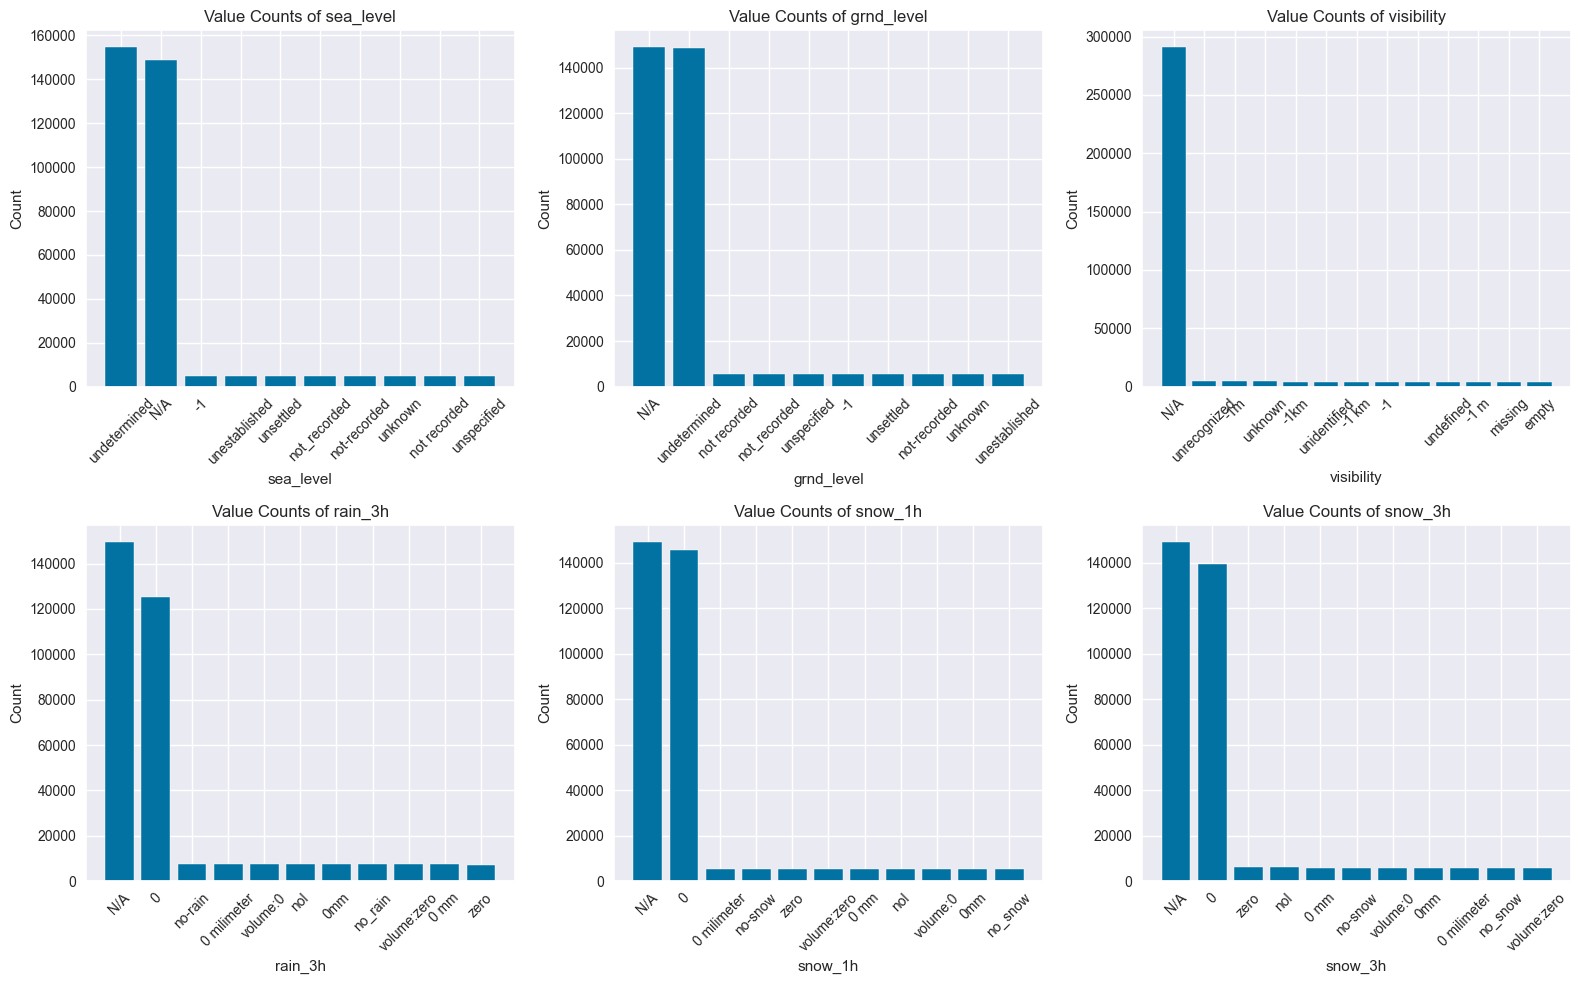

In [ ]:
columns_to_plot = ['sea_level', 'grnd_level', 'visibility', 'rain_3h', 'snow_1h', 'snow_3h']

num_columns = len(columns_to_plot)
fig, axes = plt.subplots(2, num_columns // 2, figsize=(16, 10))

axes = axes.flatten()
for i, column in enumerate(columns_to_plot):
    ori_train_df[column] = ori_train_df[column].fillna("N/A")
    value_counts = ori_train_df[column].value_counts(dropna=False)

    axes[i].bar(value_counts.index, value_counts.values)
    axes[i].set_title(f'Value Counts of {column}')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

> Column `visibility`, `sea_level`, `grnd_level`, `visibility`, `rain_3h`, `snow_1h`, `snow_3h` didominasi oleh missing value dan (unrecognized, unknown, unidentified, etc.).
Oleh karena itu, column-column tersebut dianggap useless dan di drop.

In [ ]:
def clean_cols(df, is_train=True):
    df['datetime'] = pd.to_datetime(df['datetime'], unit='s')

    # function to clean unit
    def clean_unit(x):
        temp_pattern = r'-?\d+(\.\d+)?'
        regex = re.search(temp_pattern, str(x))
        return float(regex.group(0)) if regex else np.nan

    # clean unit
    df['temp'] = df['temp'].apply(clean_unit)
    df['d_point'] = df['d_point'].apply(clean_unit)
    df['feels'] = df['feels'].apply(clean_unit)
    df['min_temp'] = df['min_temp'].apply(clean_unit)
    df['max_temp'] = df['max_temp'].apply(clean_unit)
    df['prssr'] = df['prssr'].apply(clean_unit)
    df['hum'] = df['hum'].apply(clean_unit)
    df['wind_spd'] = df['wind_spd'].apply(clean_unit)
    df['wind_deg'] = df['wind_deg'].apply(clean_unit)
    df['clouds'] = df['clouds'].apply(clean_unit)

    # clean rain_1h
    if is_train:
        df.loc[df['rain_1h'] == 'zero', 'rain_1h'] = 0
        df.loc[df['rain_1h'] == ' ', 'rain_1h'] = 0
        df['rain_1h'] = df['rain_1h'].apply(clean_unit)
        df.loc[df['rain_1h'] < 0, 'rain_1h'] = 0

    # drop useless columns
    df.drop([
        'datetime_iso',
        'time-zone',
        'visibility',
        'sea_level',
        'grnd_level',
        'rain_3h',
        'snow_1h',
        'snow_3h'
    ], axis=1, inplace=True)

    return df

In [ ]:
train_df = ori_train_df.copy()
train_df = clean_cols(train_df)
train_df.head()

,datetime,temp,d_point,feels,min_temp,max_temp,prssr,hum,wind_spd,wind_deg,rain_1h,clouds
0,1979-01-01 00:00:00,24.75,23.89,25.76,24.28,25.22,1012.0,95.0,0.82,320.0,0.00,100.0
1,1979-01-01 01:00:00,24.58,23.73,25.57,23.99,25.26,1012.0,95.0,0.96,338.0,0.00,100.0
2,1979-01-01 02:00:00,26.60,24.06,26.60,26.10,27.39,1012.0,86.0,1.22,339.0,0.00,99.0
3,1979-01-01 03:00:00,27.31,24.37,30.90,26.59,28.36,1012.0,84.0,1.08,342.0,0.13,94.0
4,1979-01-01 04:00:00,27.41,25.05,31.54,26.58,28.31,1011.0,87.0,0.86,336.0,0.34,100.0


In [ ]:
test_df = ori_test_df.copy()
test_df = clean_cols(test_df, is_train=False)
test_df.loc[test_df.d_point.isnull(), ['temp', 'feels', 'min_temp', 'max_temp']] = np.nan
test_df.fillna(method='bfill', inplace=True)
test_df.loc[48707, :]

datetime    2023-07-23 11:00:00
temp                      27.36
d_point                   24.61
feels                     31.15
min_temp                  26.75
max_temp                  28.12
prssr                    1010.0
hum                         0.0
wind_spd                   2.41
wind_deg                  170.0
clouds                     97.0
Name: 48707, dtype: object

## EDA

### Monthly Trend

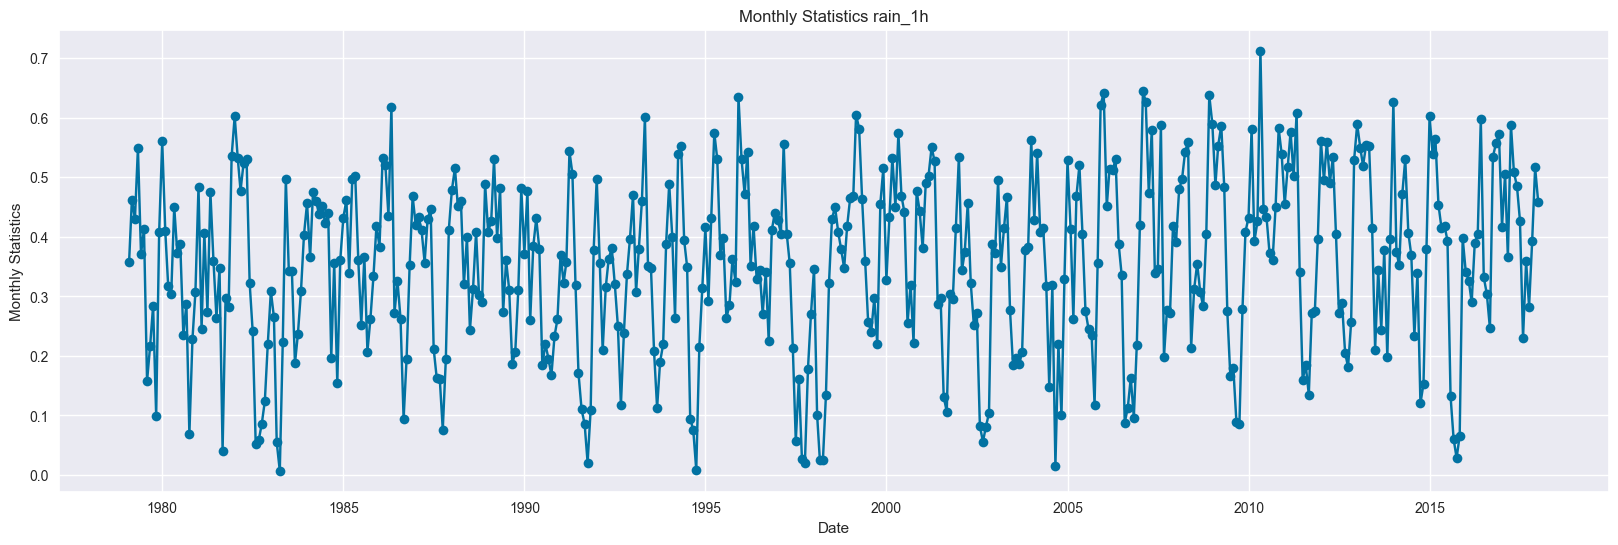

In [ ]:
# monthly data agg
monthly_data = train_df.set_index('datetime').resample('M').agg({
    'rain_1h': 'mean',
    'temp' : 'mean'
})

plt.figure(figsize=(20, 6))
plt.plot(monthly_data.index, monthly_data['rain_1h'], marker='o', linestyle='-')
plt.xlabel('Date')
plt.ylabel('Monthly Statistics')
plt.title('Monthly Statistics rain_1h')
plt.grid(True)
plt.show()

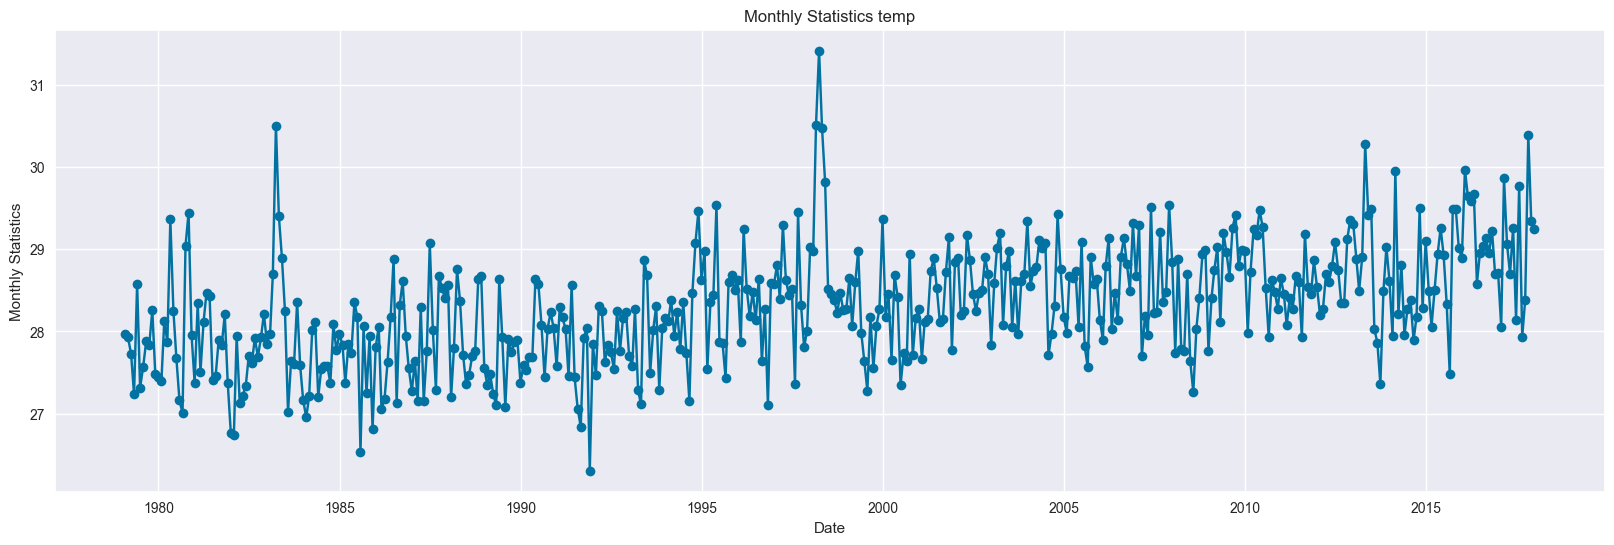

In [ ]:
plt.figure(figsize=(20, 6))
plt.plot(monthly_data.index, monthly_data['temp'], marker='o', linestyle='-')
plt.xlabel('Date')
plt.ylabel('Monthly Statistics')
plt.title('Monthly Statistics temp')
plt.grid(True)
plt.show()

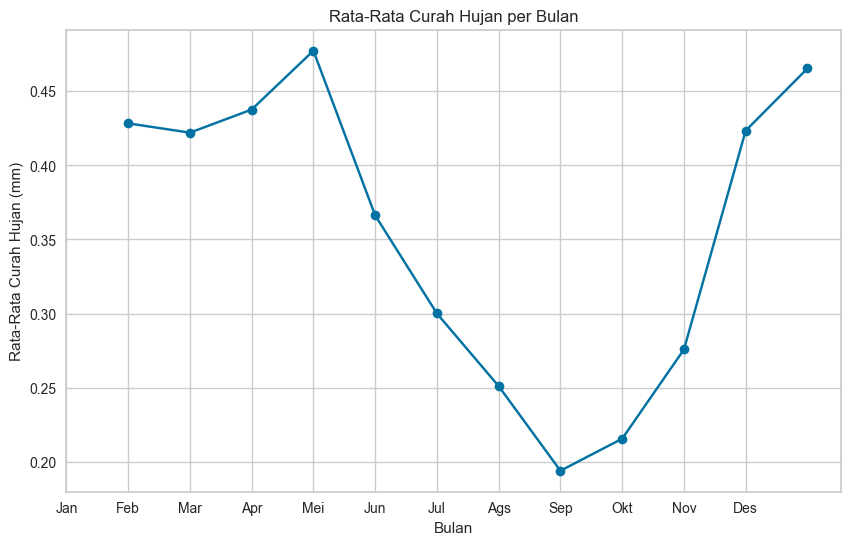

In [ ]:
monthly_avg = train_df.groupby(train_df['datetime'].dt.month)['rain_1h'].mean()

sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
plt.plot(monthly_avg.index, monthly_avg.values, marker='o', linestyle='-')
plt.title("Rata-Rata Curah Hujan per Bulan")
plt.xlabel("Bulan")
plt.ylabel("Rata-Rata Curah Hujan (mm)")
plt.xticks(range(12), ['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun', 'Jul', 'Ags', 'Sep', 'Okt', 'Nov', 'Des'])
plt.show()

> Dapat dilihat terdapat tren musiman pada data curah hujan, dimana curah hujan paling tinggi terjadi pada bulan Mei, dan paling rendah pada bulan September.

### Yearly Trend

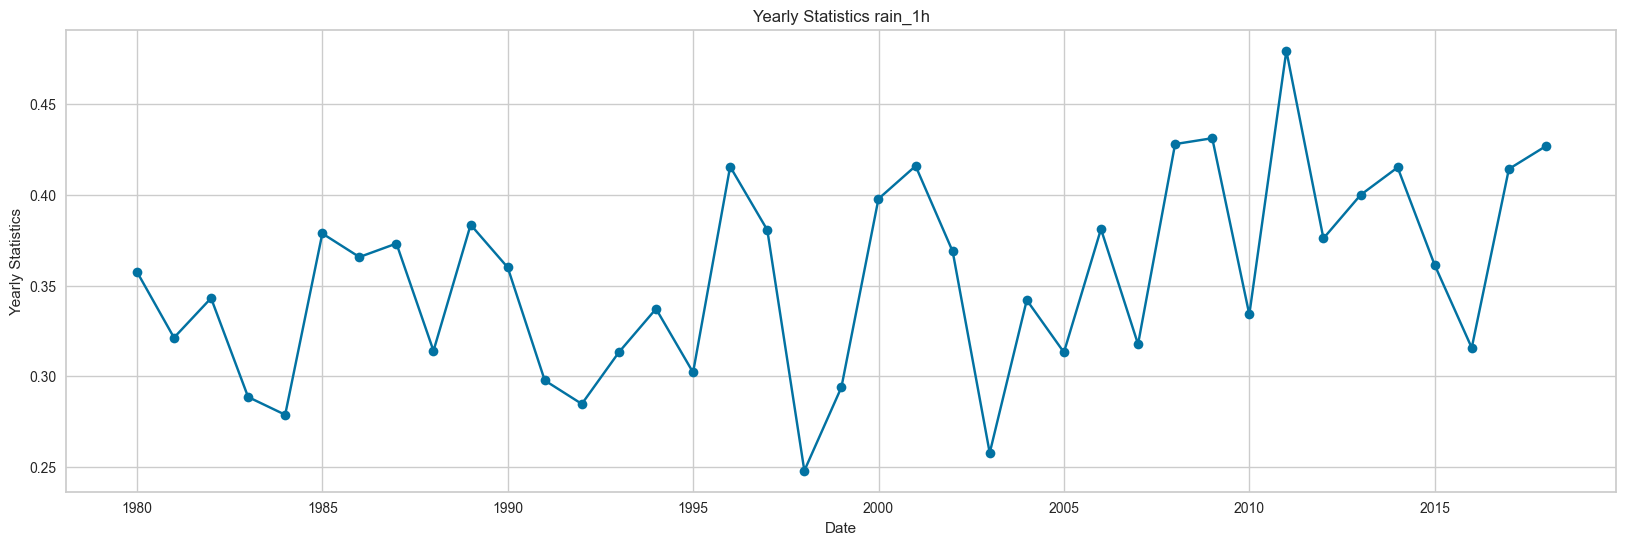

In [ ]:
# yearly data agg
yearly_data = train_df.set_index('datetime').resample('Y').agg({
    'rain_1h': 'mean',
    'temp' : 'mean'
})

plt.figure(figsize=(20, 6))
plt.plot(yearly_data.index, yearly_data['rain_1h'], marker='o', linestyle='-')
plt.xlabel('Date')
plt.ylabel('Yearly Statistics')
plt.title('Yearly Statistics rain_1h')
plt.grid(True)
plt.show()

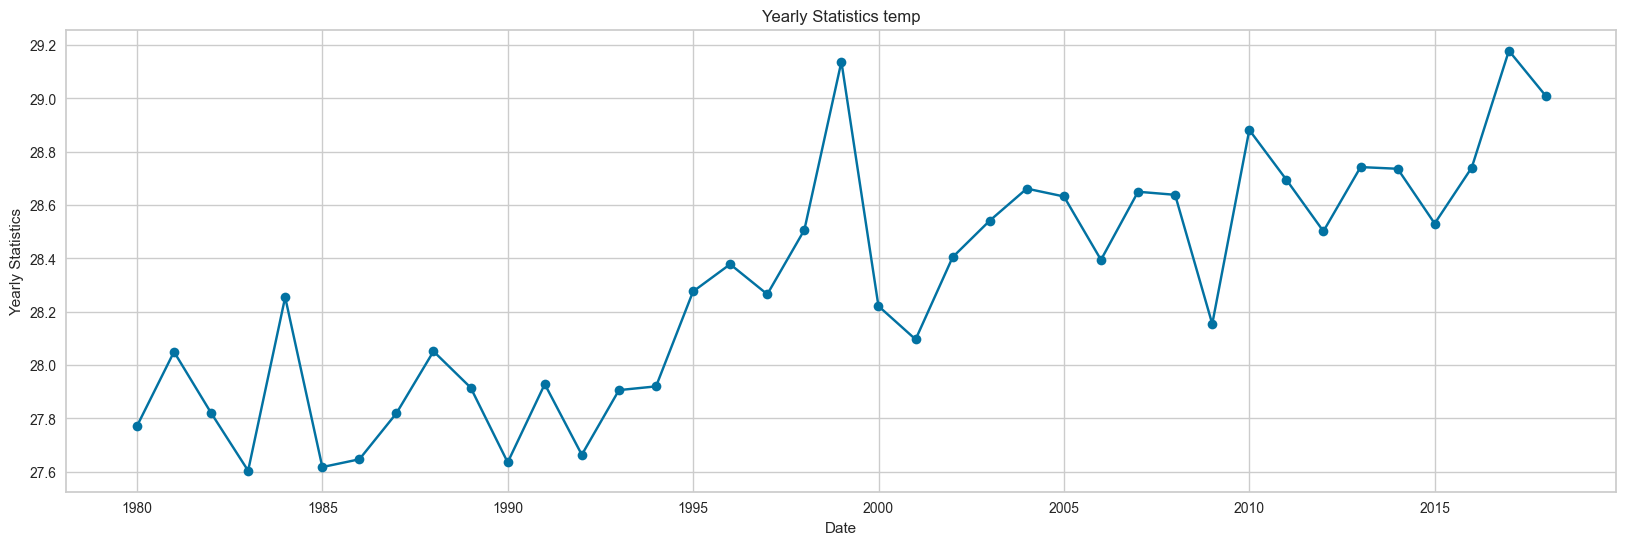

In [ ]:
plt.figure(figsize=(20, 6))
plt.plot(yearly_data.index, yearly_data['temp'], marker='o', linestyle='-')
plt.xlabel('Date')
plt.ylabel('Yearly Statistics')
plt.title('Yearly Statistics temp')
plt.grid(True)
plt.show()

> Terlihat bahwa temperatur mengalami spike yang tinggi pada 1998, "Tahun 1998 tercatat sebagai tahun paling panas, dimana temperatur saat itu satu derajat celcius lebih tinggi dari temperature rata-rata dalam durasi 1962-1990 yang sebesar 25,5 derajat celcius, ucap Rachmat Witoelar." [Referensi](https://pu.go.id/berita/indonesia-telah-alami-fenomena-penyimpangan-iklim), tapi overall temperatur memiliki trend untuk naik setiap tahunnya.

### Features correlation

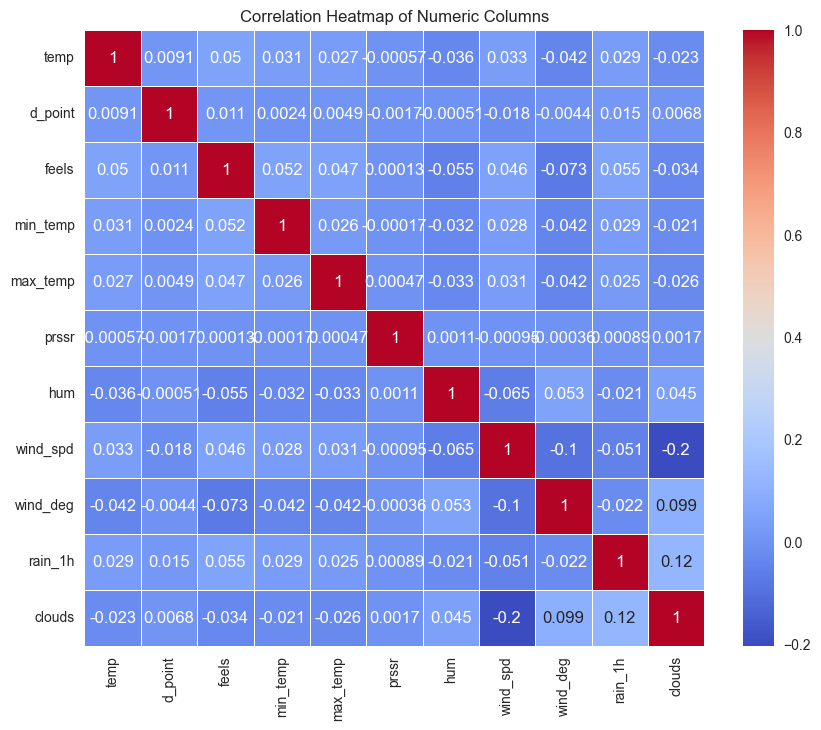

In [ ]:
numeric_cols = train_df.select_dtypes(include=['number'])
corr_matrix = numeric_cols.corr()
plt.figure(figsize=(10, 8))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=.5)

plt.title('Correlation Heatmap of Numeric Columns')

plt.show()

> Dapat dilihat bahwa fitur-fitur yang kita miliki saat ini tidak ada yang memiliki korelasi yang kuat dengan target (rain_1h), hal ini menunjukkan bahwa dibutuhkannya *feature engineering* yang kuat untuk mendapatkan fitur-fitur yang lebih baik dan kita tidak bisa hanya menggunakan model linear. Namun, beberapa fitur memiliki *multi-collinearity* seperti temp dengan max_temp, temp dengan min_temp, dll.

### First 4 Days Line Plots

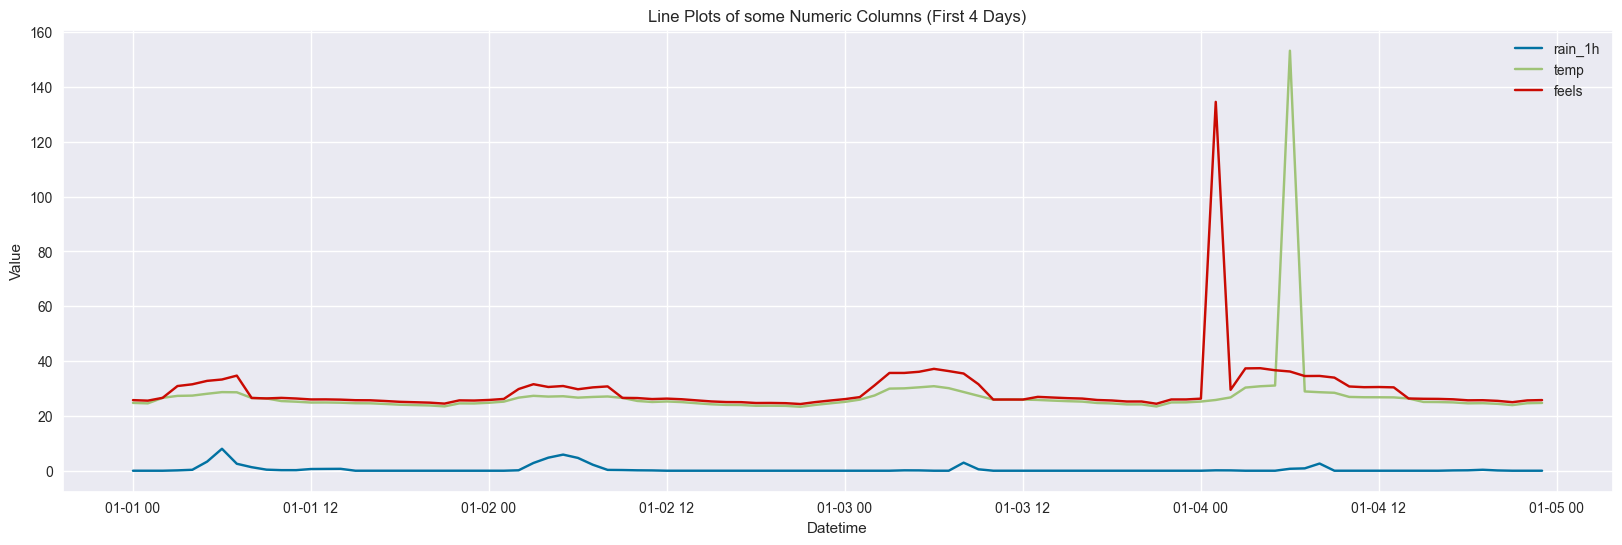

In [ ]:
start_date = train_df['datetime'].min()
end_date = start_date + pd.DateOffset(days=4)
subset_df = train_df[(train_df['datetime'] >= start_date) & (train_df['datetime'] < end_date)]
subset_df['datetime'] = pd.to_datetime(subset_df['datetime'])

numeric_cols = subset_df[['rain_1h','temp','feels']]

plt.figure(figsize=(20, 6))

for col in numeric_cols.columns:
    plt.plot(subset_df['datetime'], subset_df[col], label=col)

plt.xlabel('Datetime')
plt.ylabel('Value')
plt.title('Line Plots of some Numeric Columns (First 4 Days)')
plt.legend(loc='upper right')

plt.grid(True)
plt.show()

> Walaupun temp seharusnya dalam celcius, sepertinya ada beberapa yang dalam satuan suhu lain, dari plot diatas terlihat beberapa spike yang mencapai 130 dan 140 (tidak mungkin dalam celcius).

## Baseline

In [ ]:
X = train_df.drop([
    'rain_1h',
], axis=1)
y = train_df['rain_1h']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(273504, 11) (273504,) (68376, 11) (68376,)


In [ ]:
cbr_model = cb.CatBoostRegressor(task_type='GPU', random_state=42)
cbr_model.fit(X_train, y_train)

Learning rate set to 0.084247
0:	learn: 0.9323116	total: 4.62ms	remaining: 4.61s
1:	learn: 0.9259205	total: 8.12ms	remaining: 4.05s
2:	learn: 0.9203884	total: 11.6ms	remaining: 3.85s
3:	learn: 0.9155133	total: 15.1ms	remaining: 3.76s
4:	learn: 0.9114674	total: 19ms	remaining: 3.79s
5:	learn: 0.9078789	total: 22.4ms	remaining: 3.72s
6:	learn: 0.9048132	total: 25.8ms	remaining: 3.65s
7:	learn: 0.9019690	total: 29.2ms	remaining: 3.62s
8:	learn: 0.8995710	total: 33ms	remaining: 3.64s
9:	learn: 0.8974367	total: 36.4ms	remaining: 3.61s
10:	learn: 0.8955051	total: 39.8ms	remaining: 3.58s
11:	learn: 0.8936877	total: 43.2ms	remaining: 3.55s
12:	learn: 0.8921965	total: 46.8ms	remaining: 3.55s
13:	learn: 0.8908009	total: 50.4ms	remaining: 3.55s
14:	learn: 0.8895827	total: 53.9ms	remaining: 3.54s
15:	learn: 0.8885719	total: 57.4ms	remaining: 3.53s
16:	learn: 0.8874854	total: 60.8ms	remaining: 3.52s
17:	learn: 0.8865762	total: 64.8ms	remaining: 3.54s
18:	learn: 0.8857911	total: 68.3ms	remaining: 3.

In [ ]:
y_val_pred = cbr_model.predict(X_test)
y_val_pred = [0 if x < 0 else x for x in y_val_pred]
print(rmse(y_test, y_val_pred))

0.8583634985473081


## Handle Outliers

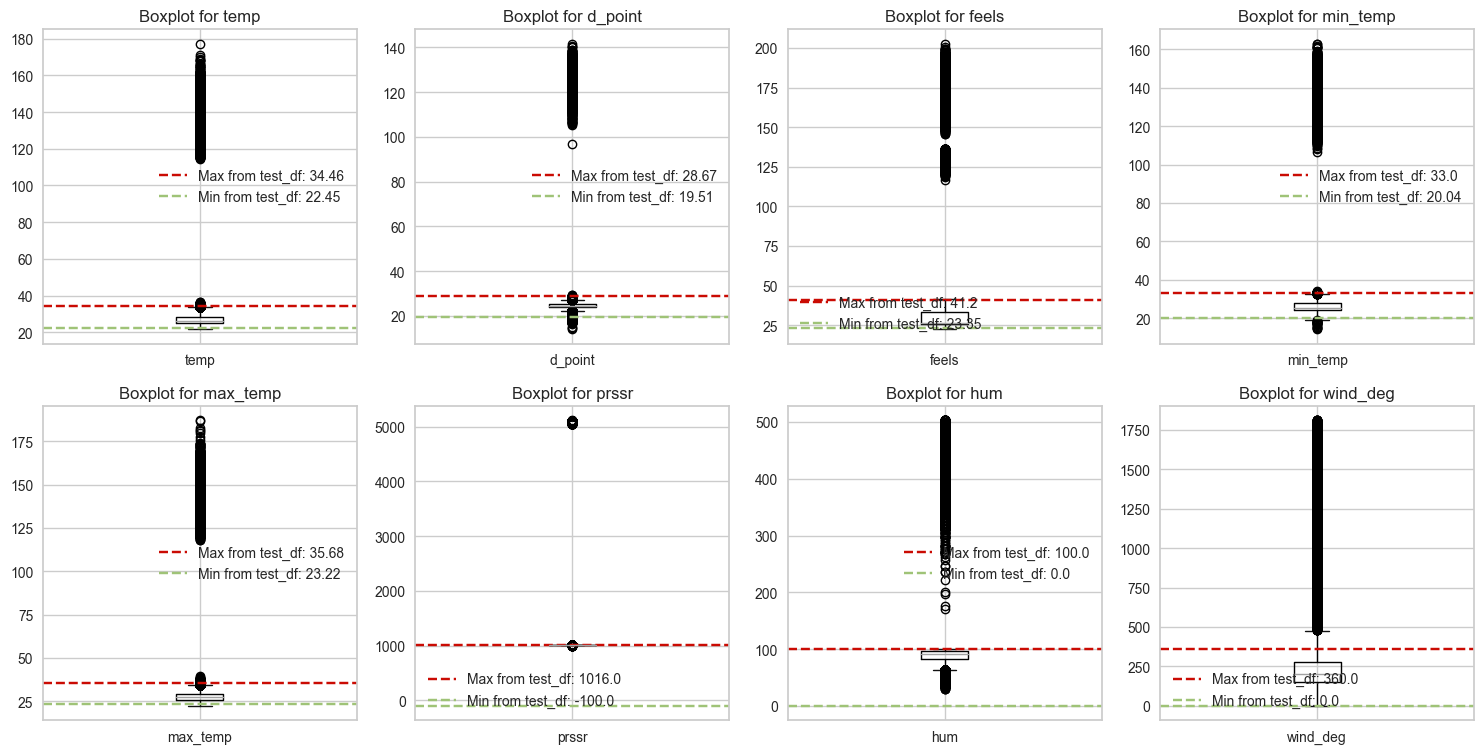

In [ ]:
plot_box(train_df, test_df)

> Delapan fitur di atas memiliki outliers yang cukup extreme. Jika dibandingkan dengan batas atas dan batas bawah dari dataset test dapat terlihat outliers tersebut sangat menyimpang. Oleh karena itu, tim kami membersihkan outliers tersebut dengan menggantinya dengan hasil regresi linear. Alasan menggunakan regresi linear untuk impute dapat dilihat pada analisis heatmap dimana kolom-kolom tersebut memiliki korelasi yang tinggi.

In [ ]:
train_df['temp'] = np.where(train_df['temp'] > 100, np.nan, train_df['temp'])
train_df['d_point'] = np.where(train_df['d_point'] > 50, np.nan, train_df['d_point'])
train_df['feels'] = np.where(train_df['feels'] > 100, np.nan, train_df['feels'])
train_df['min_temp'] = np.where(train_df['min_temp'] > 100, np.nan, train_df['min_temp'])
train_df['max_temp'] = np.where(train_df['max_temp'] > 100, np.nan, train_df['max_temp'])
train_df['prssr'] = np.where(train_df['prssr'] > 3000, np.nan, train_df['prssr'])
train_df['wind_deg'] = np.where(train_df['wind_deg'] > 360, np.nan, train_df['wind_deg'])
train_df['hum'] = np.where(train_df['hum'] > 100, np.nan, train_df['hum'])

In [ ]:
from sklearn.linear_model import LinearRegression

# impute temp
lr_model = LinearRegression()
tmp_train = train_df.loc[(train_df['temp'].notnull()) & (train_df['min_temp'].notnull()), ['min_temp', 'temp']]
tmp_test = train_df.loc[(train_df['temp'].isnull()) & (train_df['min_temp'].notnull()), 'min_temp']
lr_model.fit(tmp_train[['min_temp']].values.reshape(-1, 1), tmp_train['temp'])
train_df.loc[tmp_test.index, 'temp'] = lr_model.predict(tmp_test.values.reshape(-1, 1))
train_df['temp'].fillna(method='bfill', inplace=True)
train_df.temp.isnull().sum()

0

In [ ]:
# impute min_temp
lr_model = LinearRegression()
tmp_train = train_df.loc[train_df['min_temp'].notnull(), ['temp', 'min_temp']]
tmp_test = train_df.loc[train_df['min_temp'].isnull(), 'temp']
lr_model.fit(tmp_train[['temp']].values.reshape(-1, 1), tmp_train['min_temp'])
train_df.loc[tmp_test.index, 'min_temp'] = lr_model.predict(tmp_test.values.reshape(-1, 1))
train_df.min_temp.isnull().sum()

0

In [ ]:
# impute max_temp
lr_model = LinearRegression()
tmp_train = train_df.loc[train_df['max_temp'].notnull(), ['min_temp', 'max_temp']]
tmp_test = train_df.loc[train_df['max_temp'].isnull(), 'min_temp']
lr_model.fit(tmp_train[['min_temp']].values.reshape(-1, 1), tmp_train['max_temp'])
train_df.loc[tmp_test.index, 'max_temp'] = lr_model.predict(tmp_test.values.reshape(-1, 1))
train_df.max_temp.isnull().sum()

0

In [ ]:
# impute feels
lr_model = LinearRegression()
tmp_train = train_df.loc[(train_df['feels'].notnull()) & (train_df['temp'].notnull()), ['temp', 'feels']]
tmp_test = train_df.loc[(train_df['feels'].isnull()) & (train_df['temp'].notnull()), 'temp']
lr_model.fit(tmp_train[['temp']].values.reshape(-1, 1), tmp_train['feels'])
train_df.loc[tmp_test.index, 'feels'] = lr_model.predict(tmp_test.values.reshape(-1, 1))
train_df.feels.isnull().sum()

0

In [ ]:
train_df.fillna(method='bfill', inplace=True)
train_df.isnull().sum()

datetime    0
temp        0
d_point     0
feels       0
min_temp    0
max_temp    0
prssr       0
hum         0
wind_spd    0
wind_deg    0
rain_1h     0
clouds      0
dtype: int64

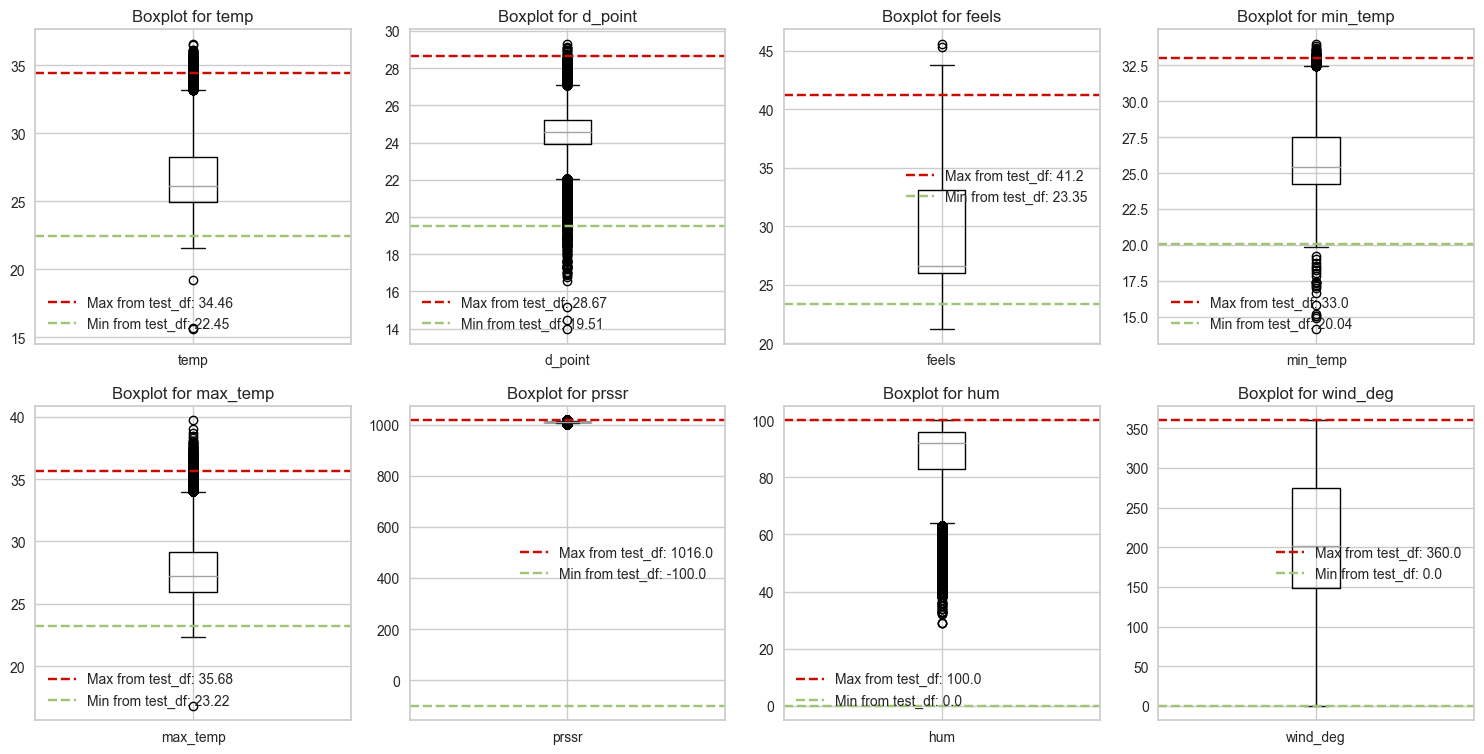

In [ ]:
plot_box(train_df, test_df)

> Setelah dilakukan remove outliers dan impute, dapat dilihat bahwa data sudah tidak memiliki outliers yang berarti.

In [ ]:
combined_df = pd.concat([train_df, test_df])
combined_df.reset_index(drop=True, inplace=True)
combined_df.head()

,datetime,temp,d_point,feels,min_temp,max_temp,prssr,hum,wind_spd,wind_deg,rain_1h,clouds
0,1979-01-01 00:00:00,24.75,23.89,25.76,24.28,25.22,1012.0,95.0,0.82,320.0,0.00,100.0
1,1979-01-01 01:00:00,24.58,23.73,25.57,23.99,25.26,1012.0,95.0,0.96,338.0,0.00,100.0
2,1979-01-01 02:00:00,26.60,24.06,26.60,26.10,27.39,1012.0,86.0,1.22,339.0,0.00,99.0
3,1979-01-01 03:00:00,27.31,24.37,30.90,26.59,28.36,1012.0,84.0,1.08,342.0,0.13,94.0
4,1979-01-01 04:00:00,27.41,25.05,31.54,26.58,28.31,1011.0,87.0,0.86,336.0,0.34,100.0


## Feature Engineering

### Time Feature

Fitur untuk ekstraksi waktu seperti bulan, jam dari datetime, serta pola berupa sin dan cos dari waktu tersebut

In [ ]:
train_df['month'] = train_df['datetime'].dt.month
train_df['hour'] = train_df['datetime'].dt.hour
train_df['dayofweek'] = train_df['datetime'].dt.dayofweek

Text(0.5, 1.0, 'Time of day signal')

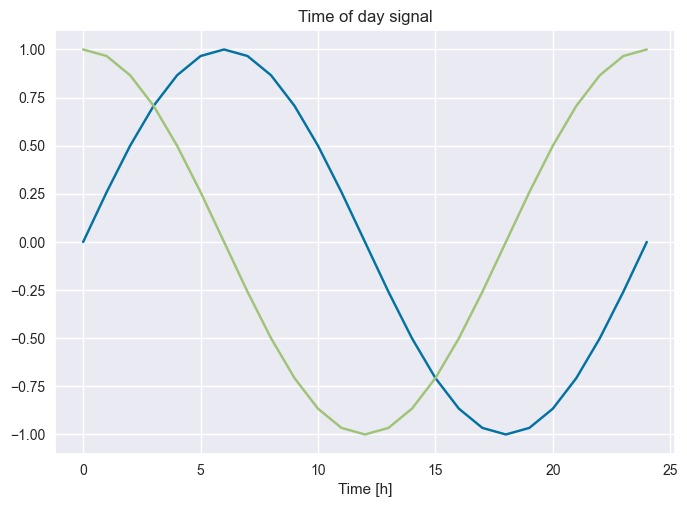

In [ ]:
timestamp_s = train_df.datetime.map(pd.Timestamp.timestamp)

day = 24 * 60 * 60
year = 365.2425 * day

train_df['day_sin'] = np.sin(timestamp_s * (2 * np.pi / day))
train_df['day_cos'] = np.cos(timestamp_s * (2 * np.pi / day))
train_df['year_sin'] = np.sin(timestamp_s * (2 * np.pi / year))
train_df['year_cos'] = np.cos(timestamp_s * (2 * np.pi / year))

plt.plot(np.array(train_df['day_sin'])[:25])
plt.plot(np.array(train_df['day_cos'])[:25])
plt.xlabel('Time [h]')
plt.title('Time of day signal')

### Lag Feature

Memberikan informasi kepada model atas data sebelumnya dengan mengubah data menjadi lagged feature.

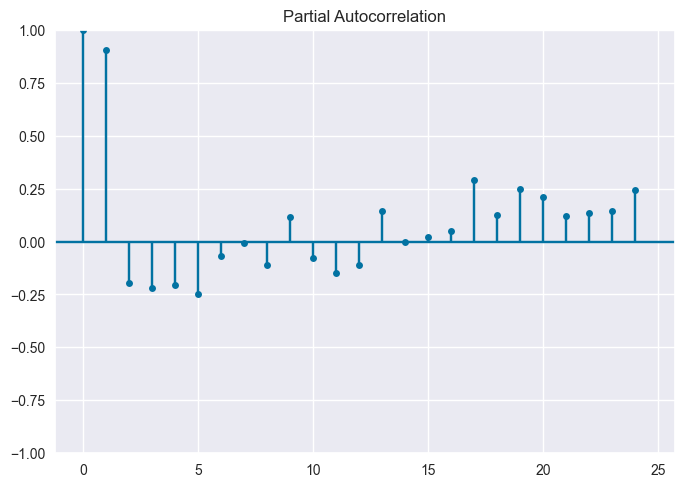

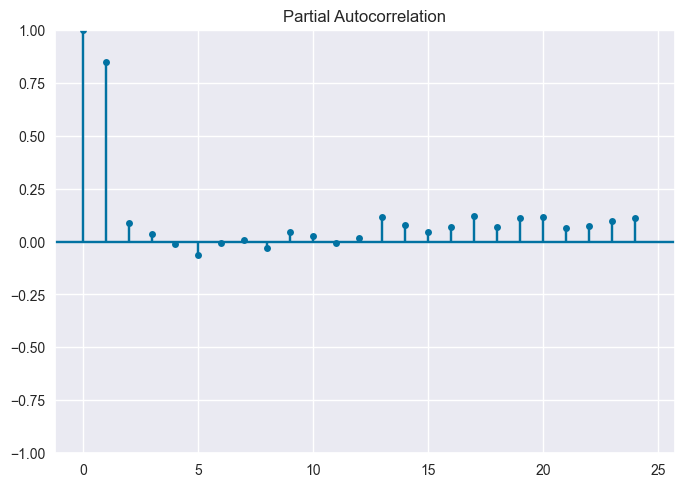

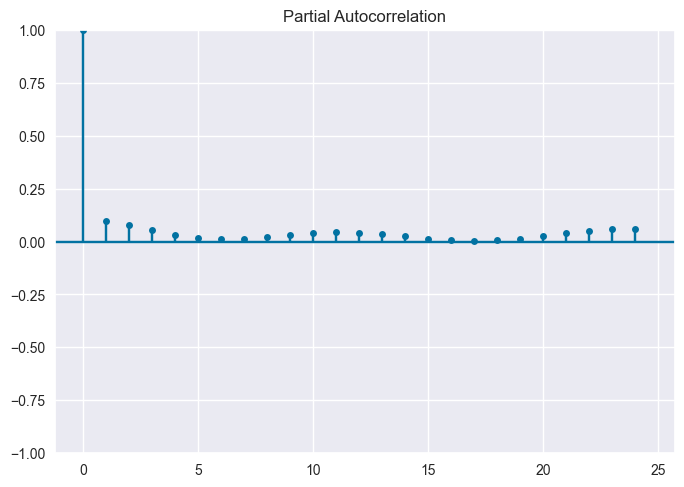

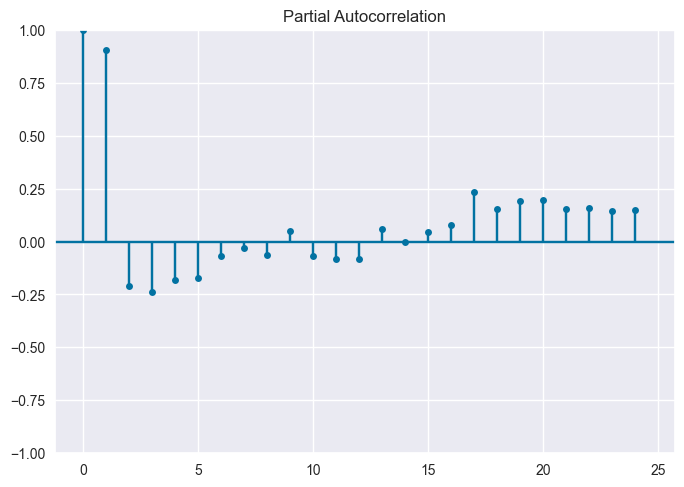

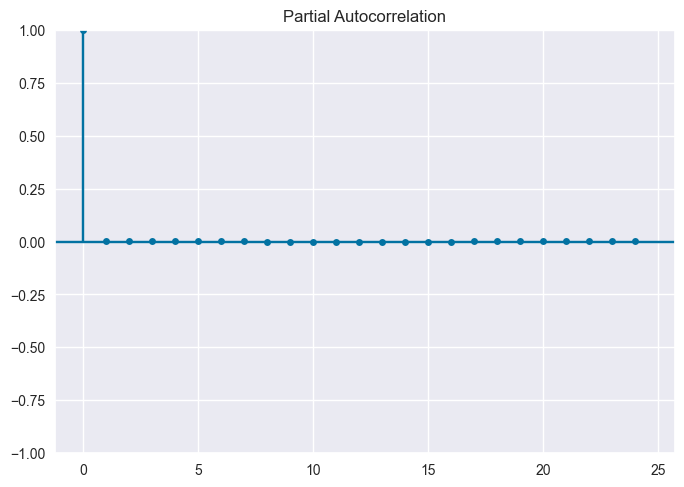

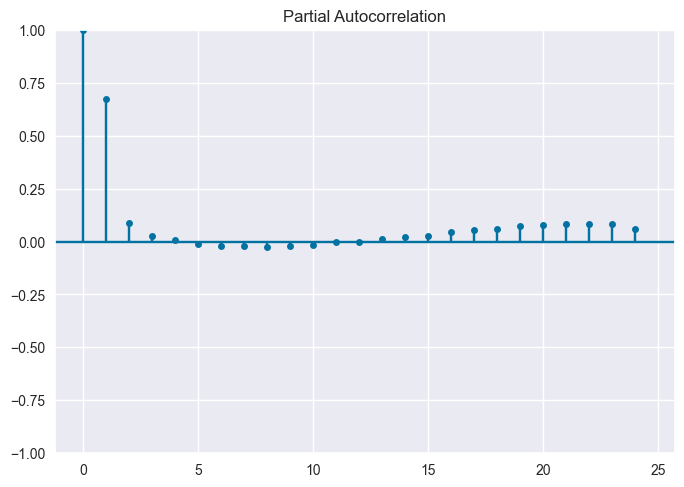

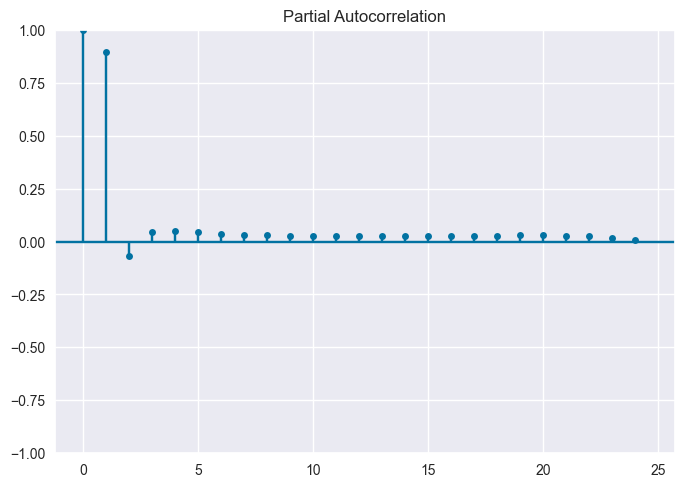

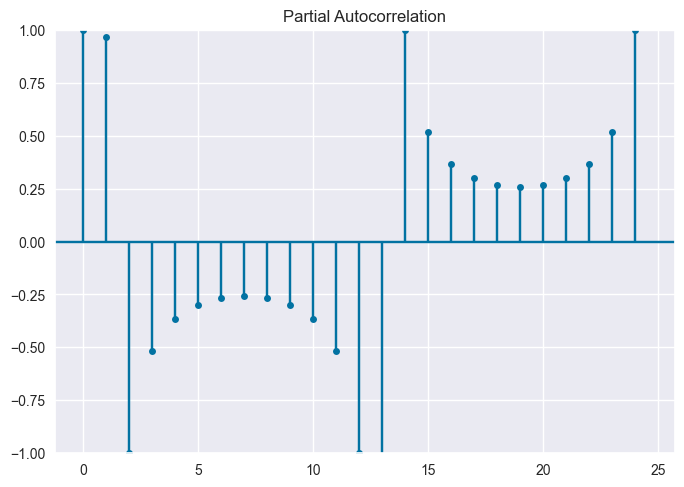

In [ ]:
_ = plot_pacf(combined_df["temp"], lags=24)
_ = plot_pacf(combined_df["d_point"], lags=24)
_ = plot_pacf(combined_df["prssr"], lags=24)
_ = plot_pacf(combined_df["hum"], lags=24)
_ = plot_pacf(combined_df["wind_spd"], lags=24)
_ = plot_pacf(combined_df["wind_deg"], lags=24)
_ = plot_pacf(combined_df["clouds"], lags=24)
_ = plot_pacf(train_df["day_sin"], lags=24)

> Membuat lag feature sesuai dengan hasil analisis *partial autocorrelation* diatas. Selain lag, dibuatkan juga inverse lag untuk data di masa depan untuk dimanfaatkan oleh model.

In [ ]:
# temp
for i in [1, 2, 3, 4, 5, 6, 8, 9, 11, 12, 13, 17, 18, 24, 24*2]:
    train_df[f'temp_lag_{i}'] = train_df['temp'].shift(i)
    train_df[f'inv_temp_lag_{i}'] = train_df['temp'].shift(-i)

# d_point
for i in [1]:
    train_df[f'd_point_lag_{i}'] = train_df['d_point'].shift(i)
    train_df[f'inv_d_point_lag_{i}'] = train_df['d_point'].shift(-i)

# hum
for i in [1, 2, 3, 4, 5, 17, 18, 19, 20, 21, 22]:
    train_df[f'hum_lag_{i}'] = train_df['hum'].shift(i)
    train_df[f'inv_hum_lag_{i}'] = train_df['hum'].shift(-i)

# wind_deg
for i in [1, 2]:
    train_df[f'wind_deg_lag_{i}'] = train_df['wind_deg'].shift(i)
    train_df[f'inv_wind_deg_lag_{i}'] = train_df['wind_deg'].shift(-i)

# cloud
for i in [1, 2]:
    train_df[f'clouds_lag_{i}'] = train_df['clouds'].shift(i)
    train_df[f'inv_clouds_lag_{i}'] = train_df['clouds'].shift(-i)

# day sin
for i in [1, 2]:
    train_df[f'day_sin_lag_{i}'] = train_df['day_sin'].shift(i)
    train_df[f'inv_day_sin_lag_{i}'] = train_df['day_sin'].shift(-i)

### Diff Feature

Berdasarkan fitur lag sebelumnya dan sedikit modifikasi, dibuatkan diff feature untuk mendapatkan perubahan data dari waktu ke waktu.

In [ ]:
# temp
for i in [1, 2, 3, 4, 24*2, 24*7]:
    train_df[f"temp_diff_{i}"] = train_df["temp"].diff(i)
    train_df[f"temp_diff_{i}"].fillna(0, inplace=True)

    train_df[f"inv_temp_diff_{i}"] = train_df["temp"].diff(-i)
    train_df[f"inv_temp_diff_{i}"].fillna(0, inplace=True)

# d_point
for i in [1]:
    train_df[f"d_point_diff_{i}"] = train_df["d_point"].diff(i)
    train_df[f"d_point_diff_{i}"].fillna(0, inplace=True)

# hum
for i in [1, 2, 3, 4, 5, 17, 18, 19, 20]:
    train_df[f"hum_diff_{i}"] = train_df["hum"].diff(i)
    train_df[f"hum_diff_{i}"].fillna(0, inplace=True)

    train_df[f"inv_hum_diff_{i}"] = train_df["hum"].diff(-i)
    train_df[f"inv_hum_diff_{i}"].fillna(0, inplace=True)

# wind_spd
for i in [1, 2, 3, 4]:
    train_df[f"wind_spd_diff_{i}"] = train_df["wind_spd"].diff(i)
    train_df[f"wind_spd_diff_{i}"].fillna(0, inplace=True)

    train_df[f"inv_wind_spd_diff_{i}"] = train_df["wind_spd"].diff(-i)
    train_df[f"inv_wind_spd_diff_{i}"].fillna(0, inplace=True)

# wind_deg
for i in [1, 2]:
    train_df[f"wind_deg_diff_{i}"] = train_df["wind_deg"].diff(i)
    train_df[f"wind_deg_diff_{i}"].fillna(0, inplace=True)

# prssr
for i in [1]:
    train_df[f"prssr_diff_{i}"] = train_df["prssr"].diff(i)
    train_df[f"prssr_diff_{i}"].fillna(0, inplace=True)

### Rolling Stats Feature

Untuk mendapatkan informasi statistik dari data sebelumnya, dibuatkan rolling stats feature seperti rolling mean, median, std, min, dan max.

In [ ]:
for time_window in [6, 720, 8640]:
    # temp
    train_df[f'{time_window}_temp_mean'] = train_df['temp'].rolling(time_window, min_periods=1).mean()
    train_df[f'{time_window}_temp_median'] = train_df['temp'].rolling(time_window, min_periods=1).median()
    train_df[f'{time_window}_temp_min'] = train_df['temp'].rolling(time_window, min_periods=1).min()
    train_df[f'{time_window}_temp_max'] = train_df['temp'].rolling(time_window, min_periods=1).max()
    train_df = train_df.iloc[::-1]
    train_df[f'{time_window}_temp_mean_rev'] = train_df['temp'].rolling(time_window, min_periods=1).mean()
    train_df[f'{time_window}_temp_median_rev'] = train_df['temp'].rolling(time_window, min_periods=1).median()
    train_df[f'{time_window}_temp_min_rev'] = train_df['temp'].rolling(time_window, min_periods=1).min()
    train_df[f'{time_window}_temp_max_rev'] = train_df['temp'].rolling(time_window, min_periods=1).max()
    train_df = train_df.iloc[::-1]

    # hum
    train_df[f'{time_window}_hum_mean'] = train_df['hum'].rolling(time_window, min_periods=1).mean()
    train_df[f'{time_window}_hum_median'] = train_df['hum'].rolling(time_window, min_periods=1).median()
    train_df[f'{time_window}_hum_min'] = train_df['hum'].rolling(time_window, min_periods=1).min()
    train_df[f'{time_window}_hum_max'] = train_df['hum'].rolling(time_window, min_periods=1).max()
    train_df = train_df.iloc[::-1]
    train_df[f'{time_window}_hum_mean_rev'] = train_df['hum'].rolling(time_window, min_periods=1).mean()
    train_df[f'{time_window}_hum_median_rev'] = train_df['hum'].rolling(time_window, min_periods=1).median()
    train_df[f'{time_window}_hum_min_rev'] = train_df['hum'].rolling(time_window, min_periods=1).min()
    train_df[f'{time_window}_hum_max_rev'] = train_df['hum'].rolling(time_window, min_periods=1).max()
    train_df = train_df.iloc[::-1]

    # wind_spd
    train_df[f'{time_window}_wind_spd_mean'] = train_df['wind_spd'].rolling(time_window, min_periods=1).mean()
    train_df[f'{time_window}_wind_spd_median'] = train_df['wind_spd'].rolling(time_window, min_periods=1).median()
    train_df[f'{time_window}_wind_spd_std'] = train_df['wind_spd'].rolling(time_window, min_periods=1).std()
    train_df[f'{time_window}_wind_spd_min'] = train_df['wind_spd'].rolling(time_window, min_periods=1).min()
    train_df[f'{time_window}_wind_spd_max'] = train_df['wind_spd'].rolling(time_window, min_periods=1).max()
    train_df = train_df.iloc[::-1]
    train_df[f'{time_window}_wind_spd_mean_rev'] = train_df['wind_spd'].rolling(time_window, min_periods=1).mean()
    train_df[f'{time_window}_wind_spd_median_rev'] = train_df['wind_spd'].rolling(time_window, min_periods=1).median()
    train_df[f'{time_window}_wind_spd_std_rev'] = train_df['wind_spd'].rolling(time_window, min_periods=1).std()
    train_df[f'{time_window}_wind_spd_min_rev'] = train_df['wind_spd'].rolling(time_window, min_periods=1).min()
    train_df[f'{time_window}_wind_spd_max_rev'] = train_df['wind_spd'].rolling(time_window, min_periods=1).max()
    train_df = train_df.iloc[::-1]

    # wind_deg
    train_df[f'{time_window}_wind_deg_mean'] = train_df['wind_deg'].rolling(time_window, min_periods=1).mean()
    train_df[f'{time_window}_wind_deg_median'] = train_df['wind_deg'].rolling(time_window, min_periods=1).median()
    train_df[f'{time_window}_wind_deg_std'] = train_df['wind_deg'].rolling(time_window, min_periods=1).std()
    train_df[f'{time_window}_wind_deg_min'] = train_df['wind_deg'].rolling(time_window, min_periods=1).min()
    train_df[f'{time_window}_wind_deg_max'] = train_df['wind_deg'].rolling(time_window, min_periods=1).max()
    train_df = train_df.iloc[::-1]
    train_df[f'{time_window}_wind_deg_mean_rev'] = train_df['wind_deg'].rolling(time_window, min_periods=1).mean()
    train_df[f'{time_window}_wind_deg_median_rev'] = train_df['wind_deg'].rolling(time_window, min_periods=1).median()
    train_df[f'{time_window}_wind_deg_std_rev'] = train_df['wind_deg'].rolling(time_window, min_periods=1).std()
    train_df[f'{time_window}_wind_deg_min_rev'] = train_df['wind_deg'].rolling(time_window, min_periods=1).min()
    train_df[f'{time_window}_wind_deg_max_rev'] = train_df['wind_deg'].rolling(time_window, min_periods=1).max()
    train_df = train_df.iloc[::-1]

    # prssr
    train_df[f'{time_window}_prssr_mean'] = train_df['prssr'].rolling(time_window, min_periods=1).mean()
    train_df[f'{time_window}_prssr_median'] = train_df['prssr'].rolling(time_window, min_periods=1).median()
    train_df[f'{time_window}_prssr_min'] = train_df['prssr'].rolling(time_window, min_periods=1).min()
    train_df[f'{time_window}_prssr_max'] = train_df['prssr'].rolling(time_window, min_periods=1).max()
    train_df = train_df.iloc[::-1]
    train_df[f'{time_window}_prssr_mean_rev'] = train_df['prssr'].rolling(time_window, min_periods=1).mean()
    train_df[f'{time_window}_prssr_median_rev'] = train_df['prssr'].rolling(time_window, min_periods=1).median()
    train_df[f'{time_window}_prssr_std_rev'] = train_df['prssr'].rolling(time_window, min_periods=1).std()
    train_df[f'{time_window}_prssr_min_rev'] = train_df['prssr'].rolling(time_window, min_periods=1).min()
    train_df[f'{time_window}_prssr_max_rev'] = train_df['prssr'].rolling(time_window, min_periods=1).max()
    train_df = train_df.iloc[::-1]

    # cloud
    train_df[f'{time_window}_clouds_mean'] = train_df['clouds'].rolling(time_window, min_periods=1).mean()
    train_df[f'{time_window}_clouds_median'] = train_df['clouds'].rolling(time_window, min_periods=1).median()
    train_df[f'{time_window}_clouds_min'] = train_df['clouds'].rolling(time_window, min_periods=1).min()
    train_df[f'{time_window}_clouds_max'] = train_df['clouds'].rolling(time_window, min_periods=1).max()
    train_df = train_df.iloc[::-1]
    train_df[f'{time_window}_clouds_mean_rev'] = train_df['clouds'].rolling(time_window, min_periods=1).mean()
    train_df[f'{time_window}_clouds_median_rev'] = train_df['clouds'].rolling(time_window, min_periods=1).median()
    train_df[f'{time_window}_clouds_std_rev'] = train_df['clouds'].rolling(time_window, min_periods=1).std()
    train_df[f'{time_window}_clouds_min_rev'] = train_df['clouds'].rolling(time_window, min_periods=1).min()
    train_df[f'{time_window}_clouds_max_rev'] = train_df['clouds'].rolling(time_window, min_periods=1).max()
    train_df = train_df.iloc[::-1]

### Wind Vector Feature and other features

Fitur untuk mengubah representasi wind_deg dan wind_spd menjadi vektor sehingga lebih mudah dipelajari model.

Text(0, 0.5, 'Wind Velocity [m/s]')

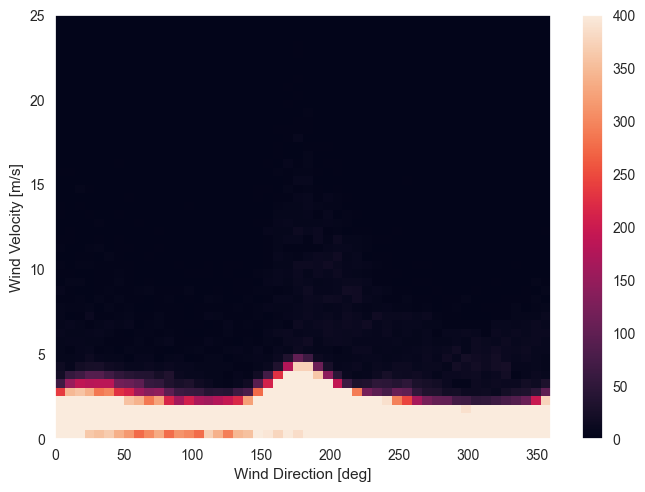

In [ ]:
plt.hist2d(train_df['wind_deg'], train_df['wind_spd'], bins=(50, 50), vmax=400)
plt.colorbar()
plt.xlabel('Wind Direction [deg]')
plt.ylabel('Wind Velocity [m/s]')

(-24.90486745229364,
 20.79086374542152,
 -16.047027500632506,
 16.677890424529835)

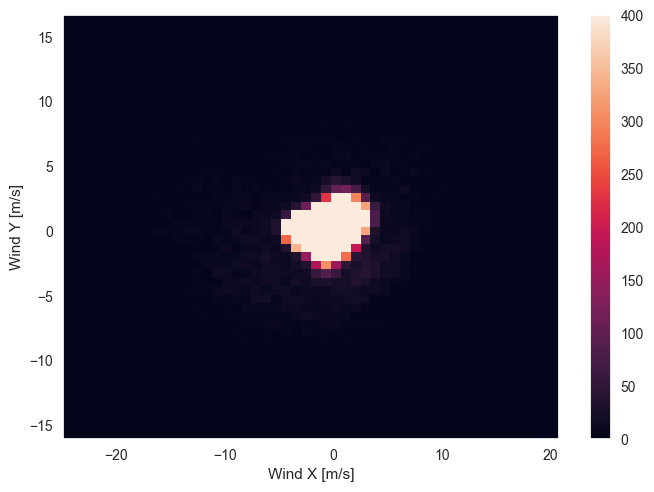

In [ ]:
# Temperature Range
train_df['temp_range'] = train_df['max_temp'] - train_df['min_temp']

# Daytime Indicator
train_df['is_daytime'] = ((train_df['hour'] >= 6) & (train_df['hour'] <= 18)).astype(int)

# convert wind speed and deg to vector
train_df['wind_y'] = train_df['wind_spd'] * np.sin(np.deg2rad(train_df['wind_deg']))
train_df['wind_x'] = train_df['wind_spd'] * np.cos(np.deg2rad(train_df['wind_deg']))

# Temperature Dew Point Spread
train_df['temp_dew_spread'] = train_df['temp'] - train_df['d_point']

# Relative Humidity
train_df['relative_hum'] = train_df['d_point'] / train_df['temp']

# plot wind_x and wind_y heatmap
plt.hist2d(train_df['wind_x'], train_df['wind_y'], bins=(50, 50), vmax=400)
plt.colorbar()
plt.xlabel('Wind X [m/s]')
plt.ylabel('Wind Y [m/s]')
ax = plt.gca()
ax.axis('tight')

Dapat dilihat bahwa distribusi data wind_x dan wind_y lebih baik dibandingkan dengan distribusi data wind_deg dan wind_spd.

### Hold-out Validation

In [ ]:
train_df.to_csv(f"{DATA_DIR}/train_ready_2.csv", index=False)

In [ ]:
train_df = pd.read_csv(f"{DATA_DIR}/train_ready_2.csv")
train_df['datetime'] = pd.to_datetime(train_df['datetime'])

In [ ]:
X = train_df.drop([
    'rain_1h',
], axis=1)
y = train_df['rain_1h']

X.drop([
    'datetime',
    'feels',
    'wind_spd',
    'wind_deg',
], axis=1, inplace=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(273504, 290) (273504,) (68376, 290) (68376,)


In [ ]:
cbr_model = cb.CatBoostRegressor(
    iterations=15000,
    max_depth=8,
    learning_rate=0.03,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    task_type='GPU',
    devices='0',
    verbose=100
)
cbr_model.fit(X_train, y_train, early_stopping_rounds=1000, eval_set=(X_test, y_test))

0:	learn: 0.9315333	test: 0.9271107	best: 0.9271107 (0)	total: 16.8ms	remaining: 4m 11s
100:	learn: 0.7373125	test: 0.7451893	best: 0.7451893 (100)	total: 1.57s	remaining: 3m 52s
200:	learn: 0.7132018	test: 0.7272449	best: 0.7272449 (200)	total: 3.02s	remaining: 3m 42s
300:	learn: 0.6982487	test: 0.7180284	best: 0.7180284 (300)	total: 4.42s	remaining: 3m 35s
400:	learn: 0.6868961	test: 0.7121289	best: 0.7121289 (400)	total: 5.81s	remaining: 3m 31s
500:	learn: 0.6771691	test: 0.7075805	best: 0.7075805 (500)	total: 7.18s	remaining: 3m 27s
600:	learn: 0.6687621	test: 0.7037142	best: 0.7037142 (600)	total: 8.54s	remaining: 3m 24s
700:	learn: 0.6617425	test: 0.7009225	best: 0.7009225 (700)	total: 9.86s	remaining: 3m 21s
800:	learn: 0.6553434	test: 0.6988038	best: 0.6988038 (800)	total: 11.2s	remaining: 3m 18s
900:	learn: 0.6487577	test: 0.6961494	best: 0.6961494 (900)	total: 12.5s	remaining: 3m 15s
1000:	learn: 0.6428414	test: 0.6945436	best: 0.6945436 (1000)	total: 13.8s	remaining: 3m 13s


In [ ]:
y_val_pred = cbr_model.predict(X_test)
y_val_pred = [0 if x < 0 else x for x in y_val_pred]
print(rmse(y_test, y_val_pred))

0.6562827602056358


## Feature Selection

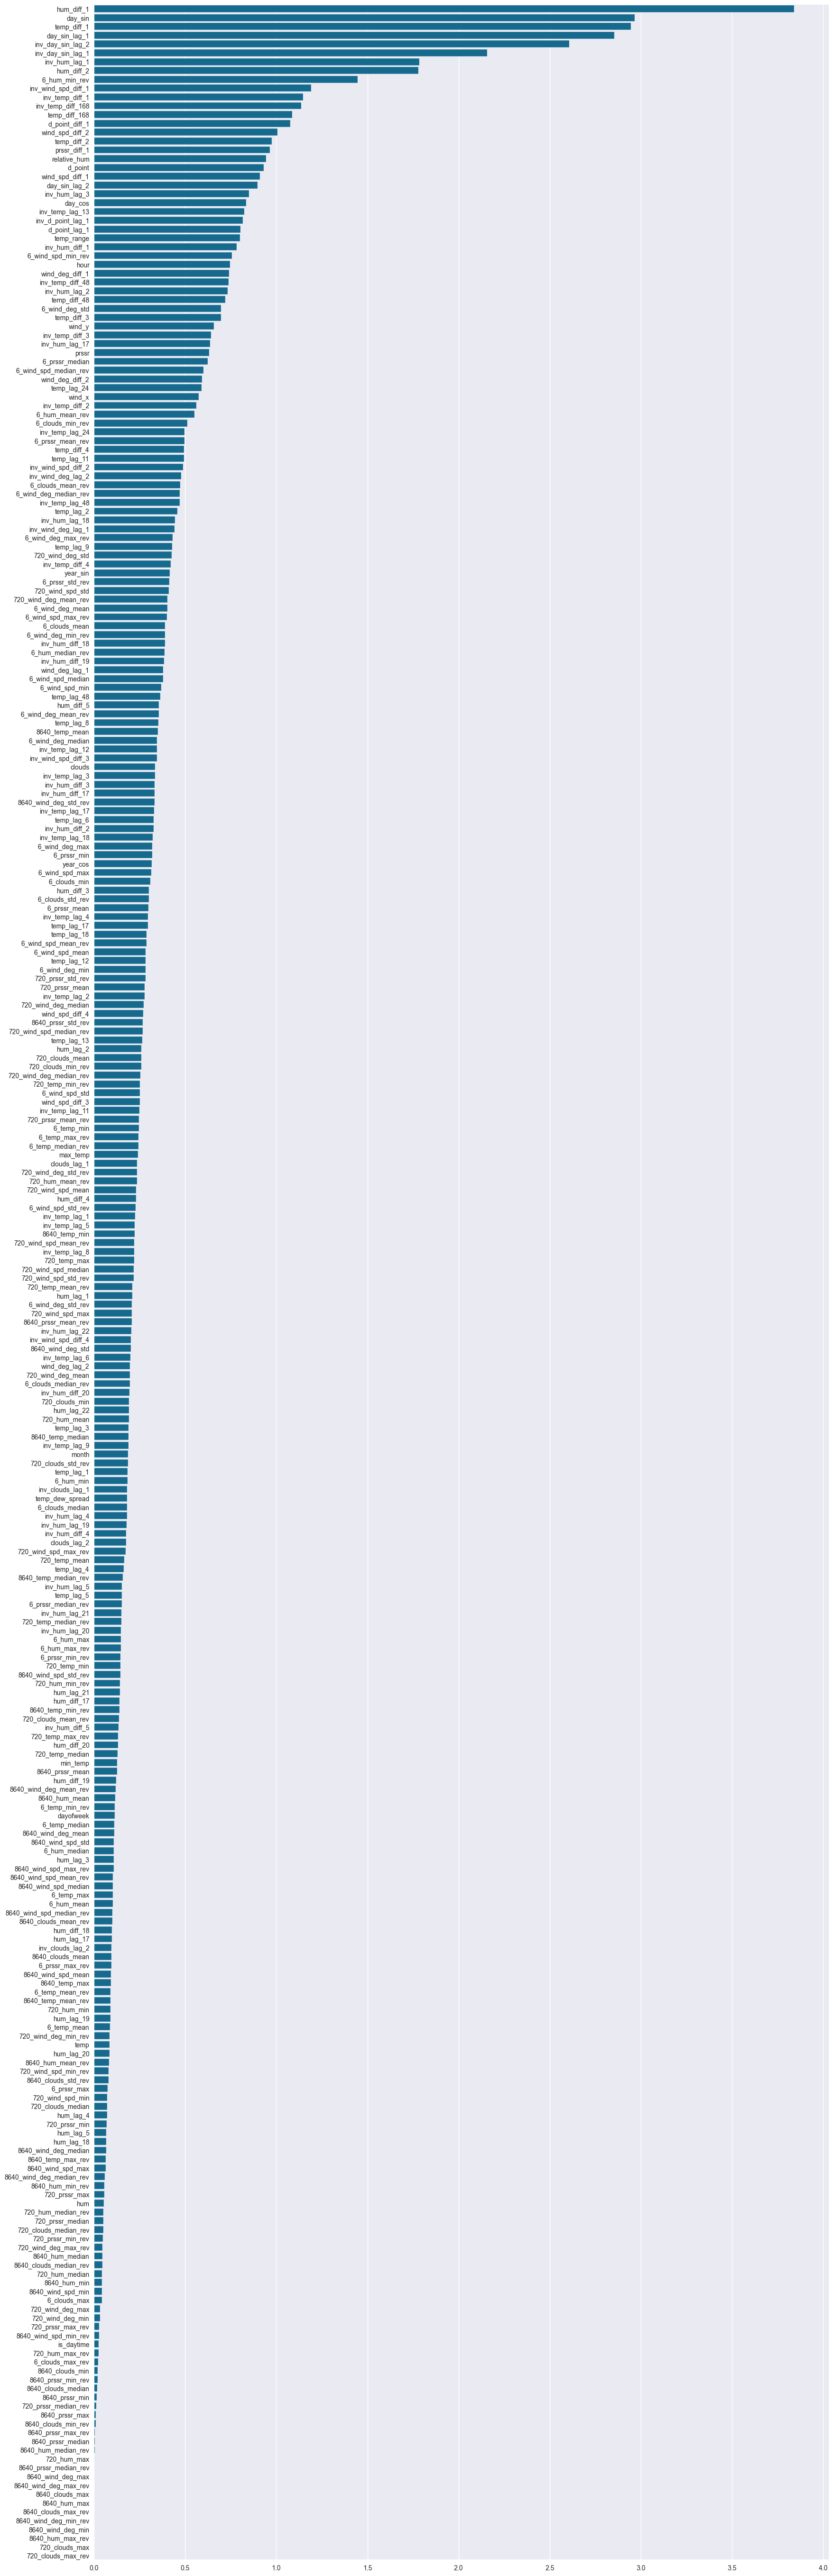

In [ ]:
# plot feature selection
plt.figure(figsize=(20, 70))
feat_importances = pd.Series(cbr_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
sns.barplot(x=feat_importances, y=feat_importances.index, color="b")
plt.show()

Trying 1 features
RMSE: 0.9128128616984489
Trying 2 features
RMSE: 0.8391067585952815
Trying 3 features
RMSE: 0.830014404887885
Trying 4 features
RMSE: 0.8090176601487469
Trying 5 features
RMSE: 0.8090659333778655
Trying 6 features
RMSE: 0.8090333807567639
Trying 7 features
RMSE: 0.7678726652390282
Trying 8 features
RMSE: 0.7619834232471222
Trying 9 features
RMSE: 0.7570914445212619
Trying 10 features
RMSE: 0.7515002436883323
Trying 11 features
RMSE: 0.7473396910518965
Trying 12 features
RMSE: 0.7469478008810004
Trying 13 features
RMSE: 0.7469598766796525
Trying 14 features
RMSE: 0.7461333228362254
Trying 15 features
RMSE: 0.7428017388158914
Trying 16 features
RMSE: 0.7408777832155374
Trying 17 features
RMSE: 0.7362931021039769
Trying 18 features
RMSE: 0.734319415526504
Trying 19 features
RMSE: 0.7322341188727546
Trying 20 features
RMSE: 0.7310724598252187
... (truncated) ...
RMSE: 0.7089881070518091
Trying 284 features
RMSE: 0.7088086521679224
Trying 285 features
RMSE: 0.7089770220406

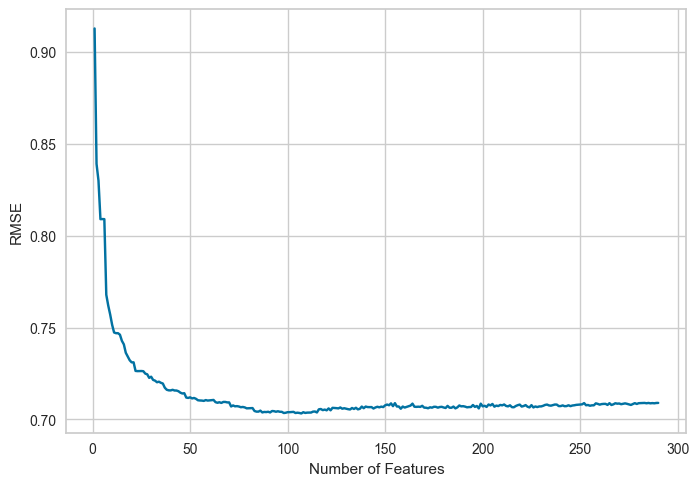

In [ ]:
# list all the scores from cross validating using features from feat_importances[:1...N]
cv_scores = []
for i in range(1, len(X.columns) + 1):
    print(f"Trying {i} features")
    selected_features = feat_importances[:i].index.tolist()
    X_selected = X[selected_features]
    cbr_model_cv = cb.CatBoostRegressor(
        loss_function='RMSE',
        eval_metric='RMSE',
        random_seed=42,
        task_type='GPU',
        devices='0',
        verbose=0
    )
    score = np.sqrt(-cross_val_score(cbr_model_cv, X_selected, y, scoring="neg_mean_squared_error", cv=5))
    cv_scores.append(score.mean())
    print(f"RMSE: {score.mean()}")

plt.plot(range(1, len(X.columns) + 1), cv_scores)
plt.xlabel("Number of Features")
plt.ylabel("RMSE")
plt.show()

Setelah melakukan feature selection secara manual, cari fitur yang buat RMSE crossval lebih tinggi (lebih jelek) dari sebelumnya dan buang.

In [ ]:
remove_feats = []
for idx, score in enumerate(cv_scores):
    if idx > 0 and score > cv_scores[idx - 1]:
        remove_feats.append(idx)

feat_importances.index[remove_feats].tolist()

['inv_day_sin_lag_2',
 'temp_diff_168',
 'day_sin_lag_2',
 'inv_temp_lag_13',
 'inv_d_point_lag_1',
 'hour',
 'temp_diff_48',
 '6_prssr_median',
 '6_hum_mean_rev',
 '6_prssr_mean_rev',
 'temp_lag_11',
 'temp_lag_2',
 'inv_wind_deg_lag_1',
 '6_wind_deg_max_rev',
 'temp_lag_9',
 'year_sin',
 '720_wind_spd_std',
 '720_wind_deg_mean_rev',
 '6_wind_deg_min_rev',
 '6_hum_median_rev',
 '6_wind_spd_median',
 'hum_diff_5',
 '6_wind_deg_mean_rev',
 'temp_lag_8',
 'inv_wind_spd_diff_3',
 'inv_temp_lag_3',
 'inv_hum_diff_17',
 'inv_temp_lag_17',
 'inv_temp_lag_18',
 '6_wind_spd_max',
 '6_clouds_min',
 'hum_diff_3',
 '6_clouds_std_rev',
 '6_prssr_mean',
 'temp_lag_17',
 '6_wind_spd_mean',
 '6_wind_deg_min',
 '720_prssr_std_rev',
 '720_prssr_mean',
 'inv_temp_lag_2',
 '720_wind_deg_median',
 '8640_prssr_std_rev',
 '720_wind_spd_median_rev',
 'hum_lag_2',
 '720_clouds_min_rev',
 '720_temp_min_rev',
 '720_prssr_mean_rev',
 '6_temp_max_rev',
 '720_wind_deg_std_rev',
 '720_wind_spd_mean',
 '6_wind_spd_s

In [ ]:
X.drop(feat_importances.index[remove_feats].tolist(), axis=1, inplace=True)
X.head()

,d_point,min_temp,max_temp,prssr,clouds,month,dayofweek,day_sin,day_cos,year_cos,inv_temp_lag_4,temp_lag_5,inv_temp_lag_5,temp_lag_6,inv_temp_lag_6,inv_temp_lag_8,inv_temp_lag_11,temp_lag_12,inv_temp_lag_12,temp_lag_13,temp_lag_18,temp_lag_24,inv_temp_lag_24,temp_lag_48,inv_temp_lag_48,d_point_lag_1,hum_lag_1,inv_hum_lag_1,inv_hum_lag_2,inv_hum_lag_3,hum_lag_4,inv_hum_lag_4,hum_lag_5,inv_hum_lag_5,hum_lag_17,inv_hum_lag_17,inv_hum_lag_18,hum_lag_21,inv_hum_lag_21,hum_lag_22,wind_deg_lag_1,inv_wind_deg_lag_2,clouds_lag_1,day_sin_lag_1,inv_day_sin_lag_1,temp_diff_1,inv_temp_diff_1,temp_diff_2,inv_temp_diff_2,temp_diff_3,inv_temp_diff_3,temp_diff_4,inv_temp_diff_4,inv_temp_diff_48,inv_temp_diff_168,d_point_diff_1,hum_diff_1,inv_hum_diff_1,hum_diff_2,inv_hum_diff_2,inv_hum_diff_3,hum_diff_4,inv_hum_diff_4,inv_hum_diff_5,inv_hum_diff_18,hum_diff_19,inv_hum_diff_19,hum_diff_20,inv_hum_diff_20,wind_spd_diff_1,inv_wind_spd_diff_1,wind_spd_diff_2,inv_wind_spd_diff_2,wind_spd_diff_3,wind_spd_diff_4,inv_wind_spd_diff_4,wind_deg_diff_1,wind_deg_diff_2,prssr_diff_1,6_temp_min,6_temp_max,6_temp_mean_rev,6_temp_median_rev,6_hum_mean,6_hum_median,6_hum_min,6_hum_max,6_hum_min_rev,6_wind_spd_std,6_wind_spd_min,6_wind_spd_mean_rev,6_wind_spd_median_rev,6_wind_spd_min_rev,6_wind_spd_max_rev,6_wind_deg_mean,6_wind_deg_median,6_wind_deg_std,6_wind_deg_max,6_wind_deg_median_rev,6_prssr_min,6_prssr_std_rev,6_prssr_max_rev,6_clouds_mean,6_clouds_median,6_clouds_mean_rev,6_clouds_median_rev,6_clouds_min_rev,720_temp_mean,720_temp_min,720_temp_median_rev,720_hum_min,720_hum_max,720_hum_mean_rev,720_hum_min_rev,720_wind_spd_median,720_wind_spd_min,720_wind_spd_max,720_wind_spd_mean_rev,720_wind_spd_min_rev,720_wind_spd_max_rev,720_wind_deg_mean,720_wind_deg_std,720_wind_deg_median_rev,720_wind_deg_max_rev,720_prssr_max_rev,720_clouds_mean,720_clouds_median,720_clouds_median_rev,720_clouds_std_rev,8640_temp_mean,8640_temp_max_rev,8640_hum_mean,8640_hum_min,8640_hum_max,8640_hum_mean_rev,8640_hum_max_rev,8640_wind_spd_mean,8640_wind_spd_min,8640_wind_spd_mean_rev,8640_wind_spd_max_rev,8640_wind_deg_mean,8640_wind_deg_std_rev,8640_wind_deg_min_rev,8640_wind_deg_max_rev,8640_prssr_max,8640_prssr_max_rev,8640_clouds_median,8640_clouds_min,8640_clouds_min_rev,temp_range,is_daytime,wind_y,wind_x,temp_dew_spread,relative_hum
0,23.89,24.28,25.22,1012.0,100.0,1,0,-6.132363e-13,1.000000,0.999995,27.41,NaN,28.08,NaN,28.68,26.55,25.19,NaN,24.88,NaN,NaN,NaN,24.80,NaN,25.13,NaN,NaN,95.0,86.0,84.0,NaN,87.0,NaN,83.0,NaN,99.0,99.0,NaN,100.0,NaN,NaN,339.0,NaN,NaN,0.258819,0.00,0.17,0.00,-1.85,0.00,-2.56,0.00,-2.66,-0.38,0.14,0.00,0.0,0.0,0.0,9.0,11.0,0.0,8.0,12.0,-4.0,0.0,-4.0,0.0,-4.0,0.00,-0.14,0.00,-0.40,0.00,0.00,-0.04,0.0,0.0,0.0,24.75,24.75,26.455000,26.955,95.0,95.0,95.0,95.0,83.0,NaN,0.82,0.963333,0.910,0.82,1.22,320.000000,320.0,NaN,320.0,337.0,1012.0,0.836660,1012.0,100.000000,100.0,98.833333,100.0,94.0,24.750,24.75,25.685,95.0,95.0,89.938889,55.0,0.82,0.82,0.82,1.320528,0.03,14.89,320.000000,NaN,237.0,360.0,1015.0,100.000000,100.0,99.0,21.963125,24.750,32.81,95.0,95.0,95.0,90.363426,100.0,0.820,0.82,1.445331,22.18,320.000000,96.344628,0.0,360.0,1012.0,1016.0,100.0,100.0,0.0,0.94,0,-0.527086,0.628156,0.86,0.965253
1,23.73,23.99,25.26,1012.0,100.0,1,0,2.588190e-01,0.965926,0.999997,28.08,NaN,28.68,NaN,28.62,26.38,24.88,NaN,24.90,NaN,NaN,NaN,25.21,NaN,25.94,23.89,95.0,86.0,84.0,87.0,NaN,83.0,NaN,77.0,NaN,99.0,99.0,NaN,99.0,NaN,320.0,342.0,100.0,-6.132363e-13,0.500000,-0.17,-2.02,0.00,-2.73,0.00,-2.83,0.00,-3.50,-1.36,-0.68,-0.16,0.0,9.0,0.0,11.0,8.0,0.0,12.0,18.0,-4.0,0.0,-4.0,0.0,-5.0,0.14,-0.26,0.00,-0.12,0.00,0.00,0.12,18.0,0.0,0.0,24.58,24.75,27.110000,27.360,95.0,95.0,95.0,95.0,77.0,0.098995,0.82,0.963333,0.910,0.82,1.22,329.000000,329.0,12.727922,338.0,337.0,1012.0,0.983192,1012.0,100.000000,100.0,98.833333,100.0,94.0,24.665,24.58,25.690,95.0,95.0,89.937500,55.0,0.89,0.82,0.96,1.321069,0.03,14.89,329.000000,12.727922,236.0,360.0,1015.0,100.000000,100.0,99.0,

Cross validation hasil feature yang sudah dilakukan proses selection.

In [ ]:
cbr_model_cv = cb.CatBoostRegressor(
    iterations=15000,
    max_depth=8,
    learning_rate=0.03,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    task_type='GPU',
    devices='0',
    verbose=100
)
np.sqrt(-cross_val_score(cbr_model_cv, X, y, scoring="neg_mean_squared_error", cv=5)).mean()

0:	learn: 0.9408096	total: 14ms	remaining: 3m 30s
100:	learn: 0.7479547	total: 1.1s	remaining: 2m 43s
200:	learn: 0.7217242	total: 2.09s	remaining: 2m 34s
300:	learn: 0.7066809	total: 3.08s	remaining: 2m 30s
400:	learn: 0.6950032	total: 4.04s	remaining: 2m 27s
500:	learn: 0.6854056	total: 5.01s	remaining: 2m 25s
600:	learn: 0.6766849	total: 5.97s	remaining: 2m 23s
700:	learn: 0.6691083	total: 6.92s	remaining: 2m 21s
800:	learn: 0.6619610	total: 7.86s	remaining: 2m 19s
900:	learn: 0.6551369	total: 8.81s	remaining: 2m 17s
1000:	learn: 0.6488200	total: 9.76s	remaining: 2m 16s
1100:	learn: 0.6430272	total: 10.7s	remaining: 2m 15s
1200:	learn: 0.6375160	total: 11.7s	remaining: 2m 13s
1300:	learn: 0.6324568	total: 12.6s	remaining: 2m 12s
1400:	learn: 0.6278779	total: 13.5s	remaining: 2m 11s
1500:	learn: 0.6230661	total: 14.5s	remaining: 2m 10s
1600:	learn: 0.6184092	total: 15.4s	remaining: 2m 9s
1700:	learn: 0.6137846	total: 16.4s	remaining: 2m 8s
1800:	learn: 0.6092559	total: 17.3s	remainin

0.6961060617557526

## Modeling

In [ ]:
X.to_csv(f"{DATA_DIR}/X_ready_final.csv", index=False)

In [ ]:
y.to_csv(f"{DATA_DIR}/y_ready_final.csv", index=False)

In [ ]:
pd.concat([X, y], axis=1).to_csv(f"{DATA_DIR}/train_ready_final.csv", index=False)

In [ ]:
cbr_model_final = cb.CatBoostRegressor(
    iterations=15000,
    max_depth=8,
    learning_rate=0.03,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    task_type='GPU',
    devices='0',
    verbose=100
)
cbr_model_final.fit(X, y, early_stopping_rounds=1000)

0:	learn: 0.9305862	total: 15ms	remaining: 3m 45s
100:	learn: 0.7393121	total: 2.04s	remaining: 5m
200:	learn: 0.7155080	total: 3.14s	remaining: 3m 50s
300:	learn: 0.7022040	total: 4.3s	remaining: 3m 30s
400:	learn: 0.6912109	total: 5.74s	remaining: 3m 28s
500:	learn: 0.6822163	total: 6.96s	remaining: 3m 21s
600:	learn: 0.6745552	total: 8.52s	remaining: 3m 24s
700:	learn: 0.6674085	total: 9.85s	remaining: 3m 20s
800:	learn: 0.6616932	total: 10.9s	remaining: 3m 13s
900:	learn: 0.6560391	total: 11.9s	remaining: 3m 6s
1000:	learn: 0.6505961	total: 12.9s	remaining: 3m 1s
1100:	learn: 0.6455291	total: 14s	remaining: 2m 56s
1200:	learn: 0.6407195	total: 15s	remaining: 2m 52s
1300:	learn: 0.6359835	total: 16s	remaining: 2m 48s
1400:	learn: 0.6314280	total: 17.1s	remaining: 2m 45s
1500:	learn: 0.6272903	total: 18.1s	remaining: 2m 42s
1600:	learn: 0.6231567	total: 20.3s	remaining: 2m 49s
1700:	learn: 0.6192191	total: 21.6s	remaining: 2m 49s
1800:	learn: 0.6149717	total: 22.7s	remaining: 2m 46s


In [ ]:
# save catboost model
cbr_model_final.save_model(f"{MODEL_DIR}/model_ThreeOutliers", format="cbm")

# save catboost model in pkl
import pickle as pkl

with open(f"{MODEL_DIR}/model_ThreeOutliers.pkl", "wb") as f:
    pkl.dump(cbr_model_final, f)

## Submission

In [ ]:
def create_features(df):
    df = df.copy()
    df['month'] = df['datetime'].dt.month
    df['hour'] = df['datetime'].dt.hour
    df['dayofweek'] = df['datetime'].dt.dayofweek

    timestamp_s = df.datetime.map(pd.Timestamp.timestamp)

    day = 24 * 60 * 60
    year = 365.2425 * day

    df['day_sin'] = np.sin(timestamp_s * (2 * np.pi / day))
    df['day_cos'] = np.cos(timestamp_s * (2 * np.pi / day))
    df['year_sin'] = np.sin(timestamp_s * (2 * np.pi / year))
    df['year_cos'] = np.cos(timestamp_s * (2 * np.pi / year))

    # temp
    for i in [1, 2, 3, 4, 5, 6, 8, 9, 11, 12, 13, 17, 18, 24, 24*2]:
        df[f'temp_lag_{i}'] = df['temp'].shift(i)
        df[f'inv_temp_lag_{i}'] = df['temp'].shift(-i)

    # d_point
    for i in [1]:
        df[f'd_point_lag_{i}'] = df['d_point'].shift(i)
        df[f'inv_d_point_lag_{i}'] = df['d_point'].shift(-i)

    # hum
    for i in [1, 2, 3, 4, 5, 17, 18, 19, 20, 21, 22]:
        df[f'hum_lag_{i}'] = df['hum'].shift(i)
        df[f'inv_hum_lag_{i}'] = df['hum'].shift(-i)

    # wind_deg
    for i in [1, 2]:
        df[f'wind_deg_lag_{i}'] = df['wind_deg'].shift(i)
        df[f'inv_wind_deg_lag_{i}'] = df['wind_deg'].shift(-i)

    # cloud
    for i in [1, 2]:
        df[f'clouds_lag_{i}'] = df['clouds'].shift(i)
        df[f'inv_clouds_lag_{i}'] = df['clouds'].shift(-i)

    # day sin
    for i in [1, 2]:
        df[f'day_sin_lag_{i}'] = df['day_sin'].shift(i)
        df[f'inv_day_sin_lag_{i}'] = df['day_sin'].shift(-i)

    # temp
    for i in [1, 2, 3, 4, 24*2, 24*7]:
        df[f"temp_diff_{i}"] = df["temp"].diff(i)
        df[f"temp_diff_{i}"].fillna(0, inplace=True)

        df[f"inv_temp_diff_{i}"] = df["temp"].diff(-i)
        df[f"inv_temp_diff_{i}"].fillna(0, inplace=True)

    # d_point
    for i in [1]:
        df[f"d_point_diff_{i}"] = df["d_point"].diff(i)
        df[f"d_point_diff_{i}"].fillna(0, inplace=True)

    # hum
    for i in [1, 2, 3, 4, 5, 17, 18, 19, 20]:
        df[f"hum_diff_{i}"] = df["hum"].diff(i)
        df[f"hum_diff_{i}"].fillna(0, inplace=True)

        df[f"inv_hum_diff_{i}"] = df["hum"].diff(-i)
        df[f"inv_hum_diff_{i}"].fillna(0, inplace=True)

    # wind_spd
    for i in [1, 2, 3, 4]:
        df[f"wind_spd_diff_{i}"] = df["wind_spd"].diff(i)
        df[f"wind_spd_diff_{i}"].fillna(0, inplace=True)

        df[f"inv_wind_spd_diff_{i}"] = df["wind_spd"].diff(-i)
        df[f"inv_wind_spd_diff_{i}"].fillna(0, inplace=True)

    # wind_deg
    for i in [1, 2]:
        df[f"wind_deg_diff_{i}"] = df["wind_deg"].diff(i)
        df[f"wind_deg_diff_{i}"].fillna(0, inplace=True)

    # prssr
    for i in [1]:
        df[f"prssr_diff_{i}"] = df["prssr"].diff(i)
        df[f"prssr_diff_{i}"].fillna(0, inplace=True)

    for time_window in [6, 720, 8640]:
        # temp
        df[f'{time_window}_temp_mean'] = df['temp'].rolling(time_window, min_periods=1).mean()
        df[f'{time_window}_temp_median'] = df['temp'].rolling(time_window, min_periods=1).median()
        df[f'{time_window}_temp_min'] = df['temp'].rolling(time_window, min_periods=1).min()
        df[f'{time_window}_temp_max'] = df['temp'].rolling(time_window, min_periods=1).max()
        df = df.iloc[::-1]
        df[f'{time_window}_temp_mean_rev'] = df['temp'].rolling(time_window, min_periods=1).mean()
        df[f'{time_window}_temp_median_rev'] = df['temp'].rolling(time_window, min_periods=1).median()
        df[f'{time_window}_temp_min_rev'] = df['temp'].rolling(time_window, min_periods=1).min()
        df[f'{time_window}_temp_max_rev'] = df['temp'].rolling(time_window, min_periods=1).max()
        df = df.iloc[::-1]

        # hum
        df[f'{time_window}_hum_mean'] = df['hum'].rolling(time_window, min_periods=1).mean()
        df[f'{time_window}_hum_median'] = df['hum'].rolling(time_window, min_periods=1).median()
        df[f'{time_window}_hum_min'] = df['hum'].rolling(time_window, min_periods=1).min()
        df[f'{time_window}_hum_max'] = df['hum'].rolling(time_window, min_periods=1).max()
        df = df.iloc[::-1]
        df[f'{time_window}_hum_mean_rev'] = df['hum'].rolling(time_window, min_periods=1).mean()
        df[f'{time_window}_hum_median_rev'] = df['hum'].rolling(time_window, min_periods=1).median()
        df[f'{time_window}_hum_min_rev'] = df['hum'].rolling(time_window, min_periods=1).min()
        df[f'{time_window}_hum_max_rev'] = df['hum'].rolling(time_window, min_periods=1).max()
        df = df.iloc[::-1]

        # wind_spd
        df[f'{time_window}_wind_spd_mean'] = df['wind_spd'].rolling(time_window, min_periods=1).mean()
        df[f'{time_window}_wind_spd_median'] = df['wind_spd'].rolling(time_window, min_periods=1).median()
        df[f'{time_window}_wind_spd_std'] = df['wind_spd'].rolling(time_window, min_periods=1).std()
        df[f'{time_window}_wind_spd_min'] = df['wind_spd'].rolling(time_window, min_periods=1).min()
        df[f'{time_window}_wind_spd_max'] = df['wind_spd'].rolling(time_window, min_periods=1).max()
        df = df.iloc[::-1]
        df[f'{time_window}_wind_spd_mean_rev'] = df['wind_spd'].rolling(time_window, min_periods=1).mean()
        df[f'{time_window}_wind_spd_median_rev'] = df['wind_spd'].rolling(time_window, min_periods=1).median()
        df[f'{time_window}_wind_spd_std_rev'] = df['wind_spd'].rolling(time_window, min_periods=1).std()
        df[f'{time_window}_wind_spd_min_rev'] = df['wind_spd'].rolling(time_window, min_periods=1).min()
        df[f'{time_window}_wind_spd_max_rev'] = df['wind_spd'].rolling(time_window, min_periods=1).max()
        df = df.iloc[::-1]

        # wind_deg
        df[f'{time_window}_wind_deg_mean'] = df['wind_deg'].rolling(time_window, min_periods=1).mean()
        df[f'{time_window}_wind_deg_median'] = df['wind_deg'].rolling(time_window, min_periods=1).median()
        df[f'{time_window}_wind_deg_std'] = df['wind_deg'].rolling(time_window, min_periods=1).std()
        df[f'{time_window}_wind_deg_min'] = df['wind_deg'].rolling(time_window, min_periods=1).min()
        df[f'{time_window}_wind_deg_max'] = df['wind_deg'].rolling(time_window, min_periods=1).max()
        df = df.iloc[::-1]
        df[f'{time_window}_wind_deg_mean_rev'] = df['wind_deg'].rolling(time_window, min_periods=1).mean()
        df[f'{time_window}_wind_deg_median_rev'] = df['wind_deg'].rolling(time_window, min_periods=1).median()
        df[f'{time_window}_wind_deg_std_rev'] = df['wind_deg'].rolling(time_window, min_periods=1).std()
        df[f'{time_window}_wind_deg_min_rev'] = df['wind_deg'].rolling(time_window, min_periods=1).min()
        df[f'{time_window}_wind_deg_max_rev'] = df['wind_deg'].rolling(time_window, min_periods=1).max()
        df = df.iloc[::-1]

        # prssr
        df[f'{time_window}_prssr_mean'] = df['prssr'].rolling(time_window, min_periods=1).mean()
        df[f'{time_window}_prssr_median'] = df['prssr'].rolling(time_window, min_periods=1).median()
        df[f'{time_window}_prssr_min'] = df['prssr'].rolling(time_window, min_periods=1).min()
        df[f'{time_window}_prssr_max'] = df['prssr'].rolling(time_window, min_periods=1).max()
        df = df.iloc[::-1]
        df[f'{time_window}_prssr_mean_rev'] = df['prssr'].rolling(time_window, min_periods=1).mean()
        df[f'{time_window}_prssr_median_rev'] = df['prssr'].rolling(time_window, min_periods=1).median()
        df[f'{time_window}_prssr_std_rev'] = df['prssr'].rolling(time_window, min_periods=1).std()
        df[f'{time_window}_prssr_min_rev'] = df['prssr'].rolling(time_window, min_periods=1).min()
        df[f'{time_window}_prssr_max_rev'] = df['prssr'].rolling(time_window, min_periods=1).max()
        df = df.iloc[::-1]

        # cloud
        df[f'{time_window}_clouds_mean'] = df['clouds'].rolling(time_window, min_periods=1).mean()
        df[f'{time_window}_clouds_median'] = df['clouds'].rolling(time_window, min_periods=1).median()
        df[f'{time_window}_clouds_min'] = df['clouds'].rolling(time_window, min_periods=1).min()
        df[f'{time_window}_clouds_max'] = df['clouds'].rolling(time_window, min_periods=1).max()
        df = df.iloc[::-1]
        df[f'{time_window}_clouds_mean_rev'] = df['clouds'].rolling(time_window, min_periods=1).mean()
        df[f'{time_window}_clouds_median_rev'] = df['clouds'].rolling(time_window, min_periods=1).median()
        df[f'{time_window}_clouds_std_rev'] = df['clouds'].rolling(time_window, min_periods=1).std()
        df[f'{time_window}_clouds_min_rev'] = df['clouds'].rolling(time_window, min_periods=1).min()
        df[f'{time_window}_clouds_max_rev'] = df['clouds'].rolling(time_window, min_periods=1).max()
        df = df.iloc[::-1]


    # Temperature Range
    df['temp_range'] = df['max_temp'] - df['min_temp']

    # Daytime Indicator
    df['is_daytime'] = ((df['hour'] >= 6) & (df['hour'] <= 18)).astype(int)

    df['wind_y'] = df['wind_spd'] * np.sin(np.deg2rad(df['wind_deg']))
    df['wind_x'] = df['wind_spd'] * np.cos(np.deg2rad(df['wind_deg']))

    df['temp_dew_spread'] = df['temp'] - df['d_point']
    df['relative_hum'] = df['d_point'] / df['temp']

    return df

Disini kita harus menggunakan combined_df untuk mengatasi fitur-fitur seperti lag, rolling, dan lain-lain yang membutuhkan data sebelumnya. Dengan menggunakan combined_df, fitur seperti temp yang ada di train bisa digunakan pada test agar tidak null.

In [ ]:
# create features for test data
test_df_final = create_features(combined_df)
test_df_final = test_df_final.loc[test_df_final['datetime'].dt.year >= 2018]
test_df_final.head()

,datetime,temp,d_point,feels,min_temp,max_temp,prssr,hum,wind_spd,wind_deg,rain_1h,clouds,month,hour,dayofweek,day_sin,day_cos,year_sin,year_cos,temp_lag_1,inv_temp_lag_1,temp_lag_2,inv_temp_lag_2,temp_lag_3,inv_temp_lag_3,temp_lag_4,inv_temp_lag_4,temp_lag_5,inv_temp_lag_5,temp_lag_6,inv_temp_lag_6,temp_lag_8,inv_temp_lag_8,temp_lag_9,inv_temp_lag_9,temp_lag_11,inv_temp_lag_11,temp_lag_12,inv_temp_lag_12,temp_lag_13,inv_temp_lag_13,temp_lag_17,inv_temp_lag_17,temp_lag_18,inv_temp_lag_18,temp_lag_24,inv_temp_lag_24,temp_lag_48,inv_temp_lag_48,d_point_lag_1,inv_d_point_lag_1,hum_lag_1,inv_hum_lag_1,hum_lag_2,inv_hum_lag_2,hum_lag_3,inv_hum_lag_3,hum_lag_4,inv_hum_lag_4,hum_lag_5,inv_hum_lag_5,hum_lag_17,inv_hum_lag_17,hum_lag_18,inv_hum_lag_18,hum_lag_19,inv_hum_lag_19,hum_lag_20,inv_hum_lag_20,hum_lag_21,inv_hum_lag_21,hum_lag_22,inv_hum_lag_22,wind_deg_lag_1,inv_wind_deg_lag_1,wind_deg_lag_2,inv_wind_deg_lag_2,clouds_lag_1,inv_clouds_lag_1,clouds_lag_2,inv_clouds_lag_2,day_sin_lag_1,inv_day_sin_lag_1,day_sin_lag_2,inv_day_sin_lag_2,temp_diff_1,inv_temp_diff_1,temp_diff_2,inv_temp_diff_2,temp_diff_3,inv_temp_diff_3,temp_diff_4,inv_temp_diff_4,temp_diff_48,inv_temp_diff_48,temp_diff_168,inv_temp_diff_168,d_point_diff_1,hum_diff_1,inv_hum_diff_1,hum_diff_2,inv_hum_diff_2,hum_diff_3,inv_hum_diff_3,hum_diff_4,inv_hum_diff_4,hum_diff_5,inv_hum_diff_5,hum_diff_17,inv_hum_diff_17,hum_diff_18,inv_hum_diff_18,hum_diff_19,inv_hum_diff_19,hum_diff_20,inv_hum_diff_20,wind_spd_diff_1,inv_wind_spd_diff_1,wind_spd_diff_2,inv_wind_spd_diff_2,wind_spd_diff_3,inv_wind_spd_diff_3,wind_spd_diff_4,inv_wind_spd_diff_4,wind_deg_diff_1,wind_deg_diff_2,prssr_diff_1,6_temp_mean,6_temp_median,6_temp_min,6_temp_max,6_temp_mean_rev,6_temp_median_rev,6_temp_min_rev,6_temp_max_rev,6_hum_mean,6_hum_median,6_hum_min,6_hum_max,6_hum_mean_rev,6_hum_median_rev,6_hum_min_rev,6_hum_max_rev,6_wind_spd_mean,6_wind_spd_median,6_wind_spd_std,6_wind_spd_min,6_wind_spd_max,6_wind_spd_mean_rev,6_wind_spd_median_rev,6_wind_spd_std_rev,6_wind_spd_min_rev,6_wind_spd_max_rev,6_wind_deg_mean,6_wind_deg_median,6_wind_deg_std,6_wind_deg_min,6_wind_deg_max,6_wind_deg_mean_rev,6_wind_deg_median_rev,6_wind_deg_std_rev,6_wind_deg_min_rev,6_wind_deg_max_rev,6_prssr_mean,6_prssr_median,6_prssr_min,6_prssr_max,6_prssr_mean_rev,6_prssr_median_rev,6_prssr_std_rev,6_prssr_min_rev,6_prssr_max_rev,6_clouds_mean,6_clouds_median,6_clouds_min,6_clouds_max,6_clouds_mean_rev,6_clouds_median_rev,6_clouds_std_rev,6_clouds_min_rev,6_clouds_max_rev,720_temp_mean,720_temp_median,720_temp_min,720_temp_max,720_temp_mean_rev,720_temp_median_rev,720_temp_min_rev,720_temp_max_rev,720_hum_mean,720_hum_median,720_hum_min,720_hum_max,720_hum_mean_rev,720_hum_median_rev,720_hum_min_rev,720_hum_max_rev,720_wind_spd_mean,720_wind_spd_median,720_wind_spd_std,720_wind_spd_min,720_wind_spd_max,720_wind_spd_mean_rev,720_wind_spd_median_rev,720_wind_spd_std_rev,720_wind_spd_min_rev,720_wind_spd_max_rev,720_wind_deg_mean,720_wind_deg_median,720_wind_deg_std,720_wind_deg_min,720_wind_deg_max,720_wind_deg_mean_rev,720_wind_deg_median_rev,720_wind_deg_std_rev,720_wind_deg_min_rev,720_wind_deg_max_rev,720_prssr_mean,720_prssr_median,720_prssr_min,720_prssr_max,720_prssr_mean_rev,720_prssr_median_rev,720_prssr_std_rev,720_prssr_min_rev,720_prssr_max_rev,720_clouds_mean,720_clouds_median,720_clouds_min,720_clouds_max,720_clouds_mean_rev,720_clouds_median_rev,720_clouds_std_rev,720_clouds_min_rev,720_clouds_max_rev,8640_temp_mean,8640_temp_median,8640_temp_min,8640_temp_max,8640_temp_mean_rev,8640_temp_median_rev,8640_temp_min_rev,8640_temp_max_rev,8640_hum_mean,8640_hum_median,8640_hum_min,8640_hum_max,8640_hum_mean_rev,8640_hum_median_rev,8640_hum_min_rev,8640_hum_max_rev,8640_wind_spd_mean,8640_wind_spd_median,8640_wind_spd_std,8640_wind_spd_min,8640_wind_spd_max,8640_wind_spd_mean_rev,8640_wind_spd_median_rev,8640_wind_spd_std_rev,8640_wind_spd_min_rev,8640_wind_spd_max_rev,8640_wind_deg_mean,8640_wind_deg_median,8640_

In [ ]:
print("Ori test dataframe shape:", ori_test_df.shape)
print("Test dataframe final shape:", test_df_final.shape)

Ori test dataframe shape: (49368, 19)
Test dataframe final shape: (49368, 295)


In [ ]:
selected_feature_names = X.columns.tolist()
selected_feature_names

['d_point',
 'min_temp',
 'max_temp',
 'prssr',
 'clouds',
 'month',
 'dayofweek',
 'day_sin',
 'day_cos',
 'year_cos',
 'inv_temp_lag_4',
 'temp_lag_5',
 'inv_temp_lag_5',
 'temp_lag_6',
 'inv_temp_lag_6',
 'inv_temp_lag_8',
 'inv_temp_lag_11',
 'temp_lag_12',
 'inv_temp_lag_12',
 'temp_lag_13',
 'temp_lag_18',
 'temp_lag_24',
 'inv_temp_lag_24',
 'temp_lag_48',
 'inv_temp_lag_48',
 'd_point_lag_1',
 'hum_lag_1',
 'inv_hum_lag_1',
 'inv_hum_lag_2',
 'inv_hum_lag_3',
 'hum_lag_4',
 'inv_hum_lag_4',
 'hum_lag_5',
 'inv_hum_lag_5',
 'hum_lag_17',
 'inv_hum_lag_17',
 'inv_hum_lag_18',
 'hum_lag_21',
 'inv_hum_lag_21',
 'hum_lag_22',
 'wind_deg_lag_1',
 'inv_wind_deg_lag_2',
 'clouds_lag_1',
 'day_sin_lag_1',
 'inv_day_sin_lag_1',
 'temp_diff_1',
 'inv_temp_diff_1',
 'temp_diff_2',
 'inv_temp_diff_2',
 'temp_diff_3',
 'inv_temp_diff_3',
 'temp_diff_4',
 'inv_temp_diff_4',
 'inv_temp_diff_48',
 'inv_temp_diff_168',
 'd_point_diff_1',
 'hum_diff_1',
 'inv_hum_diff_1',
 'hum_diff_2',
 'inv_hu

In [ ]:
test_df_selected = test_df_final[selected_feature_names]
test_df_selected.head()

,d_point,min_temp,max_temp,prssr,clouds,month,dayofweek,day_sin,day_cos,year_cos,inv_temp_lag_4,temp_lag_5,inv_temp_lag_5,temp_lag_6,inv_temp_lag_6,inv_temp_lag_8,inv_temp_lag_11,temp_lag_12,inv_temp_lag_12,temp_lag_13,temp_lag_18,temp_lag_24,inv_temp_lag_24,temp_lag_48,inv_temp_lag_48,d_point_lag_1,hum_lag_1,inv_hum_lag_1,inv_hum_lag_2,inv_hum_lag_3,hum_lag_4,inv_hum_lag_4,hum_lag_5,inv_hum_lag_5,hum_lag_17,inv_hum_lag_17,inv_hum_lag_18,hum_lag_21,inv_hum_lag_21,hum_lag_22,wind_deg_lag_1,inv_wind_deg_lag_2,clouds_lag_1,day_sin_lag_1,inv_day_sin_lag_1,temp_diff_1,inv_temp_diff_1,temp_diff_2,inv_temp_diff_2,temp_diff_3,inv_temp_diff_3,temp_diff_4,inv_temp_diff_4,inv_temp_diff_48,inv_temp_diff_168,d_point_diff_1,hum_diff_1,inv_hum_diff_1,hum_diff_2,inv_hum_diff_2,inv_hum_diff_3,hum_diff_4,inv_hum_diff_4,inv_hum_diff_5,inv_hum_diff_18,hum_diff_19,inv_hum_diff_19,hum_diff_20,inv_hum_diff_20,wind_spd_diff_1,inv_wind_spd_diff_1,wind_spd_diff_2,inv_wind_spd_diff_2,wind_spd_diff_3,wind_spd_diff_4,inv_wind_spd_diff_4,wind_deg_diff_1,wind_deg_diff_2,prssr_diff_1,6_temp_min,6_temp_max,6_temp_mean_rev,6_temp_median_rev,6_hum_mean,6_hum_median,6_hum_min,6_hum_max,6_hum_min_rev,6_wind_spd_std,6_wind_spd_min,6_wind_spd_mean_rev,6_wind_spd_median_rev,6_wind_spd_min_rev,6_wind_spd_max_rev,6_wind_deg_mean,6_wind_deg_median,6_wind_deg_std,6_wind_deg_max,6_wind_deg_median_rev,6_prssr_min,6_prssr_std_rev,6_prssr_max_rev,6_clouds_mean,6_clouds_median,6_clouds_mean_rev,6_clouds_median_rev,6_clouds_min_rev,720_temp_mean,720_temp_min,720_temp_median_rev,720_hum_min,720_hum_max,720_hum_mean_rev,720_hum_min_rev,720_wind_spd_median,720_wind_spd_min,720_wind_spd_max,720_wind_spd_mean_rev,720_wind_spd_min_rev,720_wind_spd_max_rev,720_wind_deg_mean,720_wind_deg_std,720_wind_deg_median_rev,720_wind_deg_max_rev,720_prssr_max_rev,720_clouds_mean,720_clouds_median,720_clouds_median_rev,720_clouds_std_rev,8640_temp_mean,8640_temp_max_rev,8640_hum_mean,8640_hum_min,8640_hum_max,8640_hum_mean_rev,8640_hum_max_rev,8640_wind_spd_mean,8640_wind_spd_min,8640_wind_spd_mean_rev,8640_wind_spd_max_rev,8640_wind_deg_mean,8640_wind_deg_std_rev,8640_wind_deg_min_rev,8640_wind_deg_max_rev,8640_prssr_max,8640_prssr_max_rev,8640_clouds_median,8640_clouds_min,8640_clouds_min_rev,temp_range,is_daytime,wind_y,wind_x,temp_dew_spread,relative_hum
341880,23.66,26.02,27.16,1009.0,97.0,1,0,-2.389847e-12,1.000000,0.999981,29.75,25.06,30.09,25.11,30.38,29.66,26.51,27.55,26.76,28.53,30.92,24.92,25.53,25.99,27.10,24.90,91.0,91.0,84.0,81.0,98.0,74.0,97.0,83.0,84.0,96.0,99.0,76.0,97.0,79.0,6.0,345.0,99.0,-2.588190e-01,0.258819,0.10,0.08,-0.09,-2.09,1.96,-2.25,2.08,-3.16,-0.51,1.06,-1.24,-7.0,-7.0,-5.0,0.0,3.0,-14.0,10.0,1.0,-15.0,18.0,-14.0,14.0,-13.0,-0.11,-0.22,-0.01,-0.27,-0.09,0.60,0.06,349.0,338.0,1.0,24.51,26.68,28.410000,28.760,92.833333,94.0,84.0,98.0,74.0,0.327272,0.85,1.373333,1.470,0.52,1.72,73.000000,19.0,138.319919,355.0,342.0,1006.0,1.264911,1009.0,98.333333,98.5,89.666667,93.0,69.0,27.448893,23.85,26.6,60.0,100.0,87.922222,53.0,1.275,0.07,15.09,1.130931,0.07,2.67,228.089806,81.265793,252.5,360.0,1013.0,94.766667,99.0,100.0,7.807481,27.183894,34.12,88.507060,52.0,100.0,87.523958,100.0,1.429323,0.02,1.458131,4.43,205.285742,84.960065,0.0,360.0,1016.0,1015.0,98.0,0.0,0.0,1.14,0,-0.126376,1.444482,2.93,0.889808
341881,24.92,26.06,28.04,1009.0,95.0,1,0,2.588190e-01,0.965926,0.999976,30.09,24.51,30.38,25.06,30.55,29.31,26.76,27.80,26.67,27.55,29.96,25.42,26.01,26.14,26.78,23.66,84.0,84.0,81.0,74.0,98.0,83.0,98.0,81.0,84.0,99.0,98.0,70.0,94.0,76.0,355.0,339.0,97.0,-2.389847e-12,0.500000,-0.08,-2.17,0.02,-2.33,-0.17,-3.24,1.88,-3.58,-0.27,0.66,1.26,7.0,7.0,0.0,10.0,17.0,-7.0,8.0,10.0,-7.0,20.0,-6.0,25.0,-6.0,0.22,-0.05,0.11,0.18,0.21,0.13,1.15,-4.0,345.0,0.0,24.51,26.68,29.041667,29.295,91.833333,91.0,84.0,98.0,74.0,0.291164,0.85,1.325000,1.440,0.52,1.72,129.333333,23.5,173.381275,355.0,339.0,1006.0,1.378405,1009.0,97.666667,97.5,89.500000,93.0,69.0,27.448977,23.85,26.6,60.0,100.0,87.

In [ ]:
test_df_selected.to_csv(f"{DATA_DIR}/test_ready_final.csv", index=False)

In [ ]:
# final prediction
y_test_pred = cbr_model_final.predict(test_df_selected)
y_test_pred = [0 if x < 0 else x for x in y_test_pred]
y_test_pred[:10]

[0.23073931634774492,
 0.7770445444521259,
 0.16626177023849653,
 0.022712218040385146,
 0.3790746811739716,
 4.678968557687392,
 2.925642530741271,
 2.308332633369929,
 0.8418330728022294,
 0.5962677497298289]

In [ ]:
# load sample submission
submission_df = pd.read_csv(f"{DATA_DIR}/sample_submission.csv")

# fill the target column with predictions
submission_df['datetime_iso'] = ori_test_df['datetime_iso']
submission_df['rain_1h'] = y_test_pred

# rule based
submission_df.loc[test_df[test_df.clouds == 0].index, 'rain_1h'] = 0

# save the submission file
submission_df.to_csv(f"{SUBMISSION_DIR}/submission16.csv", index=False)
submission_df.head()

,datetime_iso,rain_1h
0,2018-01-01 00:00:00+00:00,0.230739
1,2018-01-01 01:00:00+00:00,0.777045
2,2018-01-01 02:00:00+00:00,0.166262
3,2018-01-01 03:00:00+00:00,0.022712
4,2018-01-01 04:00:00+00:00,0.379075
